This notebook is used to process campaign supersaturation/humidity data.

Campaigns from 500k dataset w/ environmental data:  
- ARM: https://www.arm.gov/research/campaigns/sgp2000sprcloud
- CRYSTAL-FACE NASA: https://espoarchive.nasa.gov/archive/browse/crystalf/WB57
- CRYSTAL-FACE UND: https://espoarchive.nasa.gov/archive/browse/crystalf/Citation
- MC3E: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmmc3e-1
- MIDCIX: https://espoarchive.nasa.gov/archive/browse/midcix/WB57
- MPACE: water vapor measurements had issues. 

Other campaigns:
- OLYMPEX: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmolyx-1 (last access: 1/12/26)  

In [39]:
import pandas as pd
import os
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import polars as pl
import umap
import glob
import xarray as xr
from pathlib import Path
import re
from scipy.stats import pearsonr
from datetime import datetime, timedelta


In [2]:
env_data_path = '../data/combined_campaign_env_data.csv'
df_cocpit = pd.read_csv(env_data_path)
df_cocpit.head()

,index,filename,date,Frame Width [pixels],Frame Height [pixels],Particle Width [micrometers],Particle Height [micrometers],Cutoff [%],Aggregate [%],Budding [%],...,Altitude [m],Pressure [hPa],Temperature [C],Ice Water Content [g/m3],PSD IWC [g/m3],concentration ratio,area ratio,mass ratio,Campaign,Perimeter [pixels]
0,271,2000_0309_193624_939_28.png,2000-03-09 19:36:24,106.0,140.0,174.632,248.420,0.00,12.598,78.102,...,8847.020703,314.452612,-44.526981,0.020192,0.040985,0.000000,0.000000,0.000000,ARM,NaN
1,6544,2000_0312_235820_253_18.png,2000-03-12 23:58:20,205.0,228.0,405.842,475.640,0.00,0.030,0.000,...,5489.247559,505.781403,-21.561199,0.142520,0.095309,0.000226,0.007562,0.010116,ARM,NaN
2,14959,2000_0313_195433_318_7.png,2000-03-13 19:54:33,232.0,202.0,411.359,441.451,0.00,0.000,0.000,...,8501.253711,330.897675,-44.473520,0.021264,0.024126,0.000000,0.000000,0.000000,ARM,NaN
3,561,2000_0309_200021_189_43.png,2000-03-09 20:00:21,88.0,97.0,137.014,171.312,0.00,0.000,0.002,...,8538.226562,329.106384,-41.710745,0.026756,0.066655,0.000000,0.000000,0.000000,ARM,NaN
4,18005,2000_0313_203846_761_13.png,2000-03-13 20:38:46,275.0,323.0,546.286,653.653,2.26,2.794,0.231,...,7008.998828,410.059528,-31.873159,0.156208,0.101433,0.001189,0.033566,0.050216,ARM,NaN


In [3]:
# Ensure timestamp in datetime and rename
df_cocpit['Timestamp'] = pd.to_datetime(df_cocpit['date'], errors='coerce')

In [4]:
df_cocpit.shape

(759632, 49)

In [8]:
# number of unique filenames in df
df_cocpit['filename'].nunique()

759626

Note: the total number is actually >700k. Not sure where 

In [6]:
# Assuming your summary dataframe has datetime columns
summary['Earliest'] = pd.to_datetime(summary['Earliest'])
summary['Latest'] = pd.to_datetime(summary['Latest'])

# Compute the campaign duration
summary['Duration'] = summary['Latest'] - summary['Earliest']

# Function to format duration nicely
def format_duration(td):
    days = td.days
    seconds = td.seconds
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = (seconds % 60)
    return f"{days}d {hours}h {minutes}m {secs}s"

# Apply formatting
summary['Campaign_Length'] = summary['Duration'].apply(format_duration)

print(summary[['Earliest', 'Latest', 'Campaign_Length']])


                             Earliest              Latest  Campaign_Length
Campaign                                                                  
ARM               2000-03-09 18:57:35 2000-03-19 15:45:03   9d 20h 47m 28s
CRYSTAL_FACE_NASA 2002-07-09 15:34:18 2002-07-29 20:12:55   20d 4h 38m 37s
CRYSTAL_FACE_UND  2002-07-03 17:30:06 2002-07-29 20:50:15    26d 3h 20m 9s
MC3E              2011-05-23 16:35:05 2011-06-02 12:26:08    9d 19h 51m 3s
MIDCIX            2004-04-19 17:03:29 2004-05-06 20:36:07   17d 3h 32m 38s
MPACE             2004-09-30 01:01:20 2004-10-21 23:57:15  21d 22h 55m 55s


# ARM

Data source: https://www.arm.gov/research/campaigns/sgp2000sprcloud (last access: 1/13/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/ARM

In [7]:
data_dir = "/home/jko/ssl-cpi-analysis/data/env/ARM"
filepaths = sorted(glob.glob(os.path.join(data_dir, "*.t4archive.gz")))

# ---------------------------
# Decode YYMMDD → datetime
# ---------------------------
def decode_date(d):
    """
    d is integer YYMMDD.
    ARM Spring 2000 ⇒ year = 2000 + YY.
    """
    d = int(d)
    year = 2000 + (d // 10000)
    month = (d % 10000) // 100
    day = d % 100
    return pd.Timestamp(year, month, day)

# ---------------------------
# Column names (your mapping)
# ---------------------------
columns = [
    "Date",
    "Time(sec)",
    "True Air Speed (m/s)",
    "Wind Speed (m/s)",
    "Wind Direction (deg)",
    "INS Heading (deg)",
    "Pitch (deg)",
    "Roll (deg)",
    "Static Pressure (mb)",
    "Pressure Altitude (m)",
    "Air Temp Rosemount (C)",
    "Dew Point EG&G (C)",
    "Dew Point Cryo (C)",
    "Frost Point Cryo (C)",
    "King LWC (g/m3)",
    "FSSP LWC (g/m3)",
    "Vertical Wind (m/s)",
    "Turbulence (eps^(1/3))",
    "Ozone (ppb)",
    "CN Conc (#/cm3)",
    "INS Latitude (deg)",
    "INS Longitude (deg)",
    "GPS Lat (deg)",
    "GPS Lon (deg)",
    "GPS Alt (m)",
    "GPS Ground Speed (m/s)",
    "FSSP Conc (#/ml)",
    "FSSP Mean Diam (µm)",
    "FSSP Mean Vol Diam (µm)",
    "1DC Conc (#/L)",
    "1DC Mean Diam (µm)",
    "1DC Mean Vol Diam (µm)",
    "2DC Conc (#/L)",
    "2DC Mean Diam (µm)",
    "2DC Mean Vol Diam (µm)",
    "2DC Shadow-Or (#/L)",
    "2DP Conc (#/L)",
    "2DP Mean Diam (µm)",
    "2DP Mean Vol Diam (µm)",
]


# ------------------------------------------------------
# Loader for a single t4archive.gz file (full decoding)
# ------------------------------------------------------
def load_t4archive(filepath):

    with gzip.open(filepath, "rb") as f:
        raw = f.read()

    dtype = ">i4"  # big-endian int32
    record_length = 39

    data = np.frombuffer(raw, dtype=dtype)
    N = data.size // record_length
    data = data.reshape((N, record_length))

    # convert to float
    data_float = data.astype(float)
    data_float[:, 1:] = data_float[:, 1:] / 1000.0 - 100.0

    df = pd.DataFrame(data_float, columns=columns)

    # decode YYMMDD → yyyy-mm-dd
    df["Date"] = df["Date"].apply(decode_date)

    # combine into full timestamp
    df["Timestamp"] = df["Date"] + pd.to_timedelta(df["Time(sec)"], unit="s")

    # add the source file for diagnostics
    df["source_file"] = os.path.basename(filepath)

    return df


# ---------------------------
# Load all files
# ---------------------------
df_all = pd.concat([load_t4archive(fp) for fp in filepaths], ignore_index=True)

print("Total combined records:", len(df_all))
df_all.head()

Total combined records: 429040


,Date,Time(sec),True Air Speed (m/s),Wind Speed (m/s),Wind Direction (deg),INS Heading (deg),Pitch (deg),Roll (deg),Static Pressure (mb),Pressure Altitude (m),...,1DC Mean Vol Diam (µm),2DC Conc (#/L),2DC Mean Diam (µm),2DC Mean Vol Diam (µm),2DC Shadow-Or (#/L),2DP Conc (#/L),2DP Mean Diam (µm),2DP Mean Vol Diam (µm),Timestamp,source_file
0,2000-03-09,66670.00,17.514,-99.0,312.428,5.1,0.307,-0.528,982.754,256.990,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.000,citation.0309001831.t4archive.gz
1,2000-03-09,66670.25,17.414,-99.0,321.000,5.1,0.307,-0.528,982.768,256.874,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.250,citation.0309001831.t4archive.gz
2,2000-03-09,66670.50,17.426,-99.0,321.000,5.1,0.307,-0.528,982.742,257.101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.500,citation.0309001831.t4archive.gz
3,2000-03-09,66670.75,17.167,-99.0,321.000,5.1,0.307,-0.528,982.763,256.918,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.750,citation.0309001831.t4archive.gz
4,2000-03-09,66671.00,17.225,-99.0,312.428,5.1,0.307,-0.528,982.754,256.990,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:11.000,citation.0309001831.t4archive.gz


In [9]:
# Compute supersaturation wrt ice from frost point in celsius

# Murphy & Koop (2005) saturation vapor pressure over ice
def es_ice_MK(T):
    """
    Saturation vapor pressure over ice (Pa)
    T in Kelvin
    """
    return np.exp(
        9.550426 
        - 5723.265 / T 
        + 3.53068 * np.log(T) 
        - 0.00728332 * T
    )

def compute_Si(frost_point_C, temperature_C):
    """
    frost_point_C : frost point in Celsius
    temperature_C : ambient air temperature in Celsius
    returns supersaturation with respect to ice Si (unitless)
    """
    Tf = frost_point_C + 273.15
    T  = temperature_C + 273.15
    
    # actual vapor pressure from frost point
    e = es_ice_MK(Tf)
    
    # saturation vapor pressure over ice at ambient temperature
    esi = es_ice_MK(T)
    
    # supersaturation
    Si = e / esi - 1
    return Si
df_all["Si"] = compute_Si(df_all["Frost Point Cryo (C)"], df_all["Air Temp Rosemount (C)"])

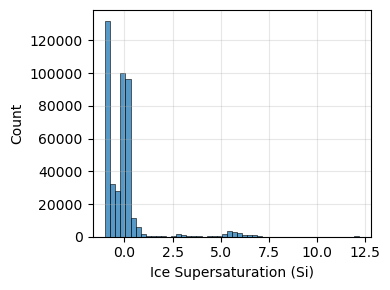

In [10]:
# distribution of Si
fp = df_all["Si"].dropna()
plt.figure(figsize=(4,3))
sns.histplot(fp, bins=50, kde=False)
plt.xlabel("Ice Supersaturation (Si)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
data_dir = '/home/jko/ssl-cpi-analysis/data/env/ARM'
filename = '/home/jko/ssl-cpi-analysis/data/env/ARM/citation.0309001831.t4archive.gz'
filepath = os.path.join(data_dir, filename)

In [ ]:
# open the gzipped binary file
with gzip.open(filepath, "rb") as f:
    raw = f.read()

# each record has 39 int32 values
record_length = 39
# dtype = np.int32
dtype = '>i4'

# interpret raw bytes as a flat array of int32
data = np.frombuffer(raw, dtype=dtype)

# reshape into (N_records, 39)
N = data.size // record_length
data = data.reshape((N, record_length))

print("Total records:", N)

In [ ]:
# copy to float array
data_float = data.astype(float)

# convert columns 2–38
data_float[:, 1:] = data_float[:, 1:] / 1000.0 - 100.0

# define dataframe columns
columns = [
    "Date",
    "Time(sec)",
    "True Air Speed (m/s)",
    "Wind Speed (m/s)",
    "Wind Direction (deg)",
    "INS Heading (deg)",
    "Pitch (deg)",
    "Roll (deg)",
    "Static Pressure (mb)",
    "Pressure Altitude (m)",
    "Air Temp Rosemount (C)",
    "Dew Point EG&G (C)",
    "Dew Point Cryo (C)",
    "Frost Point Cryo (C)",
    "King LWC (g/m3)",
    "FSSP LWC (g/m3)",
    "Vertical Wind (m/s)",
    "Turbulence (eps^(1/3))",
    "Ozone (ppb)",
    "CN Conc (#/cm3)",
    "INS Latitude (deg)",
    "INS Longitude (deg)",
    "GPS Lat (deg)",
    "GPS Lon (deg)",
    "GPS Alt (m)",
    "GPS Ground Speed (m/s)",
    "FSSP Conc (#/ml)",
    "FSSP Mean Diam (µm)",
    "FSSP Mean Vol Diam (µm)",
    "1DC Conc (#/L)",
    "1DC Mean Diam (µm)",
    "1DC Mean Vol Diam (µm)",
    "2DC Conc (#/L)",
    "2DC Mean Diam (µm)",
    "2DC Mean Vol Diam (µm)",
    "2DC Shadow-Or (#/L)",
    "2DP Conc (#/L)",
    "2DP Mean Diam (µm)",
    "2DP Mean Vol Diam (µm)",
]

# convert to pandas df
df = pd.DataFrame(data_float, columns=columns)
df.head()

In [ ]:
# convert date YYMMDD → datetime
def decode_date(d):
    year  = 2000 + int(d // 10000)   # YY → 20YY since campaign is in 2000
    month = int((d % 10000) // 100)
    day   = int(d % 100)
    return pd.Timestamp(year, month, day)

df["Date"] = df["Date"].apply(decode_date)

# time in seconds from midnight
df["Timestamp"] = df["Date"] + pd.to_timedelta(df["Time(sec)"], unit="s")

In [ ]:
df.head()

In [ ]:
# plot distribution of frost point (most relevant to humidity wrt ice)
fp = df["Frost Point Cryo (C)"].dropna()
plt.figure(figsize=(4,3))
sns.histplot(fp, bins=50, kde=False)
plt.xlabel("Frost Point (°C)")
plt.ylabel("Count")
plt.title("Distribution of Cryogenic Frost Point")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Compute supersaturation wrt ice from frost point in celsius

# Murphy & Koop (2005) saturation vapor pressure over ice
def es_ice_MK(T):
    """
    Saturation vapor pressure over ice (Pa)
    T in Kelvin
    """
    return np.exp(
        9.550426 
        - 5723.265 / T 
        + 3.53068 * np.log(T) 
        - 0.00728332 * T
    )

def compute_Si(frost_point_C, temperature_C):
    """
    frost_point_C : frost point in Celsius
    temperature_C : ambient air temperature in Celsius
    returns supersaturation with respect to ice Si (unitless)
    """
    Tf = frost_point_C + 273.15
    T  = temperature_C + 273.15
    
    # actual vapor pressure from frost point
    e = es_ice_MK(Tf)
    
    # saturation vapor pressure over ice at ambient temperature
    esi = es_ice_MK(T)
    
    # supersaturation
    Si = e / esi - 1
    return Si
df["Si"] = compute_Si(df["Frost Point Cryo (C)"], df["Air Temp Rosemount (C)"])

In [ ]:
# distribution of Si
fp = df["Si"].dropna()
plt.figure(figsize=(4,3))
sns.histplot(fp, bins=50, kde=False)
plt.xlabel("Ice Supersaturation (Si)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Plot distribution air temperature
fp = df["Air Temp Rosemount (C)"].dropna()
plt.figure(figsize=(4,3))
sns.histplot(fp, bins=50, kde=False)
plt.xlabel("Air Temp (degC)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Validating temperatures & making sure that timestamps are in the same UTC timezone.

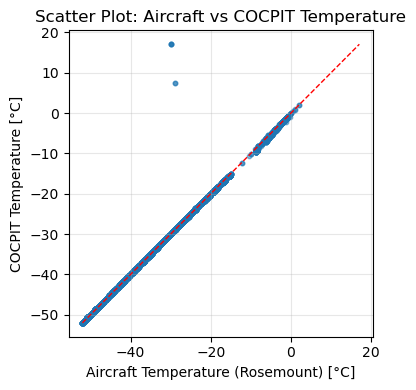

In [13]:
# compare temperatures from COCPIT env and from raw data
df=df_all
cocpit_cols = ['Timestamp', 'Temperature [C]']
raw_cols = ['Timestamp', 'Air Temp Rosemount (C)']
ta_cocpit = df_cocpit[cocpit_cols]
ta_raw = df[raw_cols]
ta_cocpit = df_cocpit.rename(columns={"Temperature [C]": "T_cocpit"})
ta_raw = df.rename(columns={"Air Temp Rosemount (C)": "T_aircraft"})
# ta_cocpit["Timestamp"] = pd.to_datetime(ta_cocpit["Timestamp"], errors='coerce')
# ta_raw["Timestamp"]    = pd.to_datetime(ta_raw["Timestamp"], errors='coerce')
merged = pd.merge(ta_raw, ta_cocpit, on="Timestamp", how="inner")
merged = merged[
    (merged["T_aircraft"] > -90) &
    (merged["T_aircraft"] < 40) &
    (merged["T_cocpit"] > -90) &
    (merged["T_cocpit"] < 40)
]
plt.figure(figsize=(4,4))

plt.scatter(
    merged["T_aircraft"],
    merged["T_cocpit"],
    s=10, alpha=0.5
)

plt.xlabel("Aircraft Temperature (Rosemount) [°C]")
plt.ylabel("COCPIT Temperature [°C]")
plt.title("Scatter Plot: Aircraft vs COCPIT Temperature")

# 1:1 reference line
min_val = min(merged["T_aircraft"].min(), merged["T_cocpit"].min())
max_val = max(merged["T_aircraft"].max(), merged["T_cocpit"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# load CPI-21K data
feat_path = '/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/CPI21K-CLS-Features/trainfeat.pth'
labels_path = '/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/CPI21K-CLS-Features/trainlabels.pth'
trainfeat = torch.load(feat_path, map_location="cpu")
trainlabels = torch.load(labels_path, map_location="cpu")

In [ ]:
df_trainfeat = pd.DataFrame(trainfeat.numpy())
print(df_trainfeat.shape)
df_trainfeat.head()

In [ ]:
df_trainlabels = pd.DataFrame(trainlabels.numpy())
print(df_trainlabels.shape)
df_trainlabels.head()

In [ ]:
# load corresponding filenames
filelist_train = pd.read_csv('/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/CPI21K-CLS-Features/filelist_train.txt', header=None)
filelist_train.rename(columns={filelist_train.columns[0]: "path"}, inplace=True)
splits = filelist_train["path"].str.split("/", expand=True)
filelist_train["filename"] = splits.iloc[:, -1]   # last element
filelist_train["habit"]    = splits.iloc[:, -2]   # second-to-last
filelist_train = filelist_train.reset_index().rename(columns={"index": "idx"})
filelist_train

In [ ]:
temp = filelist_train
count_2000 = temp["filename"].str.startswith("2000_").sum()
print(count_2000)

In [ ]:
filelist_train_merged = filelist_train.merge(
    df_cocpit[["filename", "Campaign", "Timestamp"]],
    on="filename",
    how="inner"
)
print(filelist_train.shape)
print(filelist_train_merged.shape)

In [ ]:
df_cocpit[df_cocpit['Campaign']=='ARM'].shape

In [ ]:
temp = filelist_train_merged
temp[temp['Campaign']=='ARM']

For some reason, very small sample of ARM data in CPI-21K. Going to try using CPI-3M for analysis below with ARM data.

In [17]:
# load cpi3m embeddings (from SSL Model v3)
cpi3m_path = '/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/cpi3m_campaign_cls_head_features_compressed.parquet'
scan = pl.scan_parquet(cpi3m_path)
# filter by campaign == "ARM"
cpi3m_arm = (
    scan
    .filter(pl.col("campaign") == "ARM")
    .collect()
)
print(type(cpi3m_arm))
print(cpi3m_arm.head())
# cpi3m = pd.read_parquet(cpi3m_path)
# cpi3m_arm = cpi3m[cpi3m['Campaign']=='ARM']
# cpi3m_arm.shape

<class 'polars.dataframe.frame.DataFrame'>
shape: (5, 5)
┌────────────────────────┬──────────────┬──────────┬───────────────────────┬───────────────────────┐
│ campaign_file_id       ┆ cls_features ┆ campaign ┆ filename              ┆ head_features         │
│ ---                    ┆ ---          ┆ ---      ┆ ---                   ┆ ---                   │
│ str                    ┆ list[f32]    ┆ str      ┆ str                   ┆ list[f32]             │
╞════════════════════════╪══════════════╪══════════╪═══════════════════════╪═══════════════════════╡
│ ARM/2000_0306_202027_5 ┆ [1.024477,   ┆ ARM      ┆ 2000_0306_202027_531_ ┆ [0.06622, -0.005036,  │
│ 31_20.pn…              ┆ 1.715163, …  ┆          ┆ 20.png                ┆ … -0.0933…            │
│                        ┆ 1.07379…     ┆          ┆                       ┆                       │
│ ARM/2000_0306_202027_5 ┆ [0.983172,   ┆ ARM      ┆ 2000_0306_202027_531_ ┆ [0.053725, 0.029565,  │
│ 31_27.pn…              ┆ 0.97981

In [104]:
import umap
# UMAP to reduce CLS to 3-dimensions
temp = cpi3m_arm.sample(n=100000, seed=42)
X = temp['cls_features'].to_list()
X = np.array(X, dtype=np.float32)
print("Embedding matrix:", X.shape)
# Run UMAP → 3 dimensions
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=100,
    min_dist=0.1,
    metric="cosine",
    n_jobs=-1
    # random_state=42,
)

X_umap = umap_model.fit_transform(X)
print("UMAP shape:", X_umap.shape)
# (N, 3)

Embedding matrix: (100000, 384)
UMAP shape: (100000, 3)


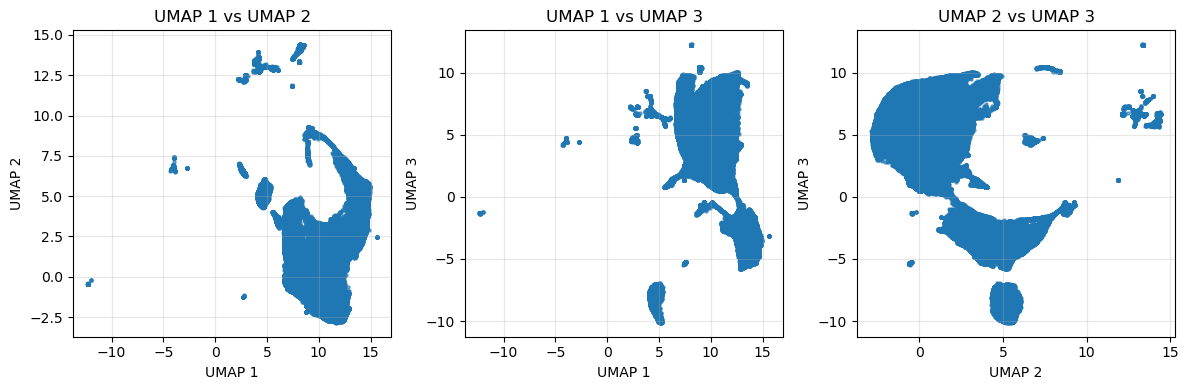

In [105]:
# plot UMAP in 3D
# Convert to named columns for clarity
umap1 = X_umap[:, 0]
umap2 = X_umap[:, 1]
umap3 = X_umap[:, 2]

# Create figure with 3 subplots
plt.figure(figsize=(12, 4))

# ---- Plot 1: UMAP1 vs UMAP2 ----
plt.subplot(1, 3, 1)
plt.scatter(umap1, umap2, s=5, alpha=0.6)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP 1 vs UMAP 2")
plt.grid(alpha=0.3)

# ---- Plot 2: UMAP1 vs UMAP3 ----
plt.subplot(1, 3, 2)
plt.scatter(umap1, umap3, s=5, alpha=0.6)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 3")
plt.title("UMAP 1 vs UMAP 3")
plt.grid(alpha=0.3)

# ---- Plot 3: UMAP2 vs UMAP3 ----
plt.subplot(1, 3, 3)
plt.scatter(umap2, umap3, s=5, alpha=0.6)
plt.xlabel("UMAP 2")
plt.ylabel("UMAP 3")
plt.title("UMAP 2 vs UMAP 3")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [106]:
# normalize UMAP embeddings to RGB
# Assume X_umap is (N, 3)
umap_norm = (X_umap - X_umap.min(axis=0)) / (X_umap.max(axis=0) - X_umap.min(axis=0))
umap_norm = np.clip(umap_norm, 0, 1)       # safety

# Convert to 0–255 uint8 RGB
rgb = (umap_norm * 255).astype(np.uint8)

print(rgb.shape)   # (N, 3)

(100000, 3)


In [107]:
# get timestamps from filenames
# Extract as a Pandas Series
fname_pd = temp.select("filename").to_pandas()["filename"]

def filename_to_timestamp(fname):
    base = "_".join(fname.split("_")[:3])  # keep YYYY_MMDD_HHMMSS
    dt = pd.to_datetime(base, format="%Y_%m%d_%H%M%S")
    return dt

timestamps = fname_pd.apply(filename_to_timestamp)
timestamps

0       2000-03-18 23:01:23
1       2000-03-13 00:28:48
2       2000-03-19 17:13:58
3       2000-03-18 22:52:34
4       2000-03-18 22:58:58
                ...        
99995   2000-03-19 18:43:21
99996   2000-03-18 23:00:05
99997   2000-03-13 00:38:59
99998   2000-03-19 17:43:40
99999   2000-03-13 21:09:55
Name: filename, Length: 100000, dtype: datetime64[ns]

In [108]:
# add associated timestamp to rgb
rgb_df = pd.DataFrame(
    rgb,
    columns=["R", "G", "B"]
)
df_rgb = pd.DataFrame({"Timestamp": timestamps}).reset_index(drop=True)
df_rgb = pd.concat([df_rgb, rgb_df], axis=1)

In [109]:
# filter environmental data to reasonable range
env = df_all[(df_all['Si']<1.0) & (df_all['Si']>-0.9)]
env.head()

,Date,Time(sec),True Air Speed (m/s),Wind Speed (m/s),Wind Direction (deg),INS Heading (deg),Pitch (deg),Roll (deg),Static Pressure (mb),Pressure Altitude (m),...,2DC Conc (#/L),2DC Mean Diam (µm),2DC Mean Vol Diam (µm),2DC Shadow-Or (#/L),2DP Conc (#/L),2DP Mean Diam (µm),2DP Mean Vol Diam (µm),Timestamp,source_file,Si
0,2000-03-09,66670.00,17.514,-99.0,312.428,5.1,0.307,-0.528,982.754,256.990,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.000,citation.0309001831.t4archive.gz,-0.484335
1,2000-03-09,66670.25,17.414,-99.0,321.000,5.1,0.307,-0.528,982.768,256.874,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.250,citation.0309001831.t4archive.gz,-0.484814
2,2000-03-09,66670.50,17.426,-99.0,321.000,5.1,0.307,-0.528,982.742,257.101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.500,citation.0309001831.t4archive.gz,-0.485816
3,2000-03-09,66670.75,17.167,-99.0,321.000,5.1,0.307,-0.528,982.763,256.918,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.750,citation.0309001831.t4archive.gz,-0.486804
4,2000-03-09,66671.00,17.225,-99.0,312.428,5.1,0.307,-0.528,982.754,256.990,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:11.000,citation.0309001831.t4archive.gz,-0.487471


In [110]:
# 1. Add an index to preserve original order
ts_df = pd.DataFrame({
    "Timestamp_query": timestamps,
    "orig_order": range(len(timestamps))
})

# 2. Sort copies for merge_asof (required)
ts_sorted = ts_df.sort_values("Timestamp_query")
env_sorted = env.sort_values("Timestamp")

# 3. Perform nearest match
matched_env = pd.merge_asof(
    ts_sorted,
    env_sorted,
    left_on="Timestamp_query",
    right_on="Timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("1s")
)

# 4. Restore original order
matched_env = matched_env.sort_values("orig_order").reset_index(drop=True)

# 5. Drop helper column if you want
matched_env = matched_env.drop(columns=["orig_order"])

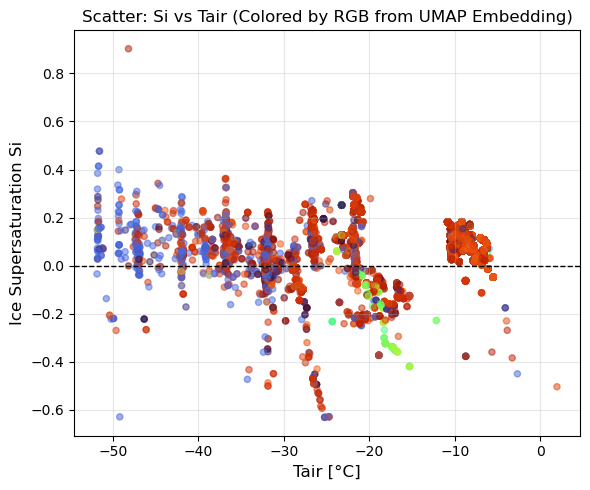

In [117]:
import colorsys
df_env_final = matched_env[['Timestamp', 'Si', 'Air Temp Rosemount (C)']]
df_final = df_rgb.merge(df_env_final, on='Timestamp', how='inner')

df_final = df_final.rename(columns={
    "Air Temp Rosemount (C)": "Tair"
})

# Pick random points (adjust as needed)
df_plot = df_final.sample(n=10000, random_state=42)

# Convert RGB columns (0–255 ints) to 0–1 floats
rgb_vals = df_plot[["R", "G", "B"]].values / 255.0


# Convert RGB → HSV → use H (hue) as scalar for colormap
hsv = np.array([colorsys.rgb_to_hsv(r,g,b) for r,g,b in rgb_vals])
hue = hsv[:,0]   # Range 0..1

# Map hue to a matplotlib colormap
cmap = plt.cm.turbo
colors = cmap(hue)
# colors = rgb_vals

plt.figure(figsize=(6, 5))

plt.scatter(
    df_plot["Tair"],
    df_plot["Si"],
    c=colors,
    s=20,
    alpha=0.5
)
# ★ Horizontal dashed line at Si = 0
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel("Tair [°C]", fontsize=12)
plt.ylabel("Ice Supersaturation Si", fontsize=12)
plt.title("Scatter: Si vs Tair (RGB -> colormap from UMAP Embedding)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [118]:
df_final.shape

(1167190, 6)

# CRYSTAL-FACE NASA

Data Source: https://espoarchive.nasa.gov/archive/browse/crystalf/WB57 (last access: 1/12/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-NASA

In [15]:
import pandas as pd
from pathlib import Path

def parse_columns(header_line):
    tokens = header_line.split()
    cols = []
    i = 0
    while i < len(tokens):
        if i + 1 < len(tokens) and tokens[i + 1].startswith("("):
            cols.append(f"{tokens[i]} {tokens[i + 1]}")
            i += 2
        else:
            cols.append(tokens[i])
            i += 1
    return cols

def read_jlh_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    n_header = int(lines[0].split()[0])

    # FIX: parse columns correctly
    columns = parse_columns(lines[n_header - 1])

    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=n_header,
        names=columns
    )

    df["source_file"] = filepath
    return df


# Directory containing files
data_dir = Path("/home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-NASA")

# Read and combine all files
dfs = [read_jlh_file(f) for f in data_dir.iterdir() if f.is_file()]
combined_df = pd.concat(dfs, ignore_index=True)

print(combined_df.head())


    UT (s)    ppmv  P(mb)   T(K)   Ep(mb)  Td(C)  Esh(mb)  Esi(mb)    %RH  \
0  64803.5  505.90  286.4  237.0  0.14489 -38.97  0.27810  0.19706  73.53   
1  64804.5  473.78  285.9  236.9  0.13545 -39.57  0.27532  0.19491  69.49   
2  64806.5  461.76  284.8  236.8  0.13151 -39.83  0.27256  0.19279  68.21   
3  64807.5  466.62  284.3  236.7  0.13266 -39.75  0.26982  0.19068  69.57   
4  64808.5  467.65  283.8  236.6  0.13272 -39.75  0.26712  0.18860  70.37   

     g/kg                                        source_file  
0  0.3162  /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FA...  
1  0.2961  /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FA...  
2  0.2886  /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FA...  
3  0.2916  /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FA...  
4  0.2923  /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FA...  


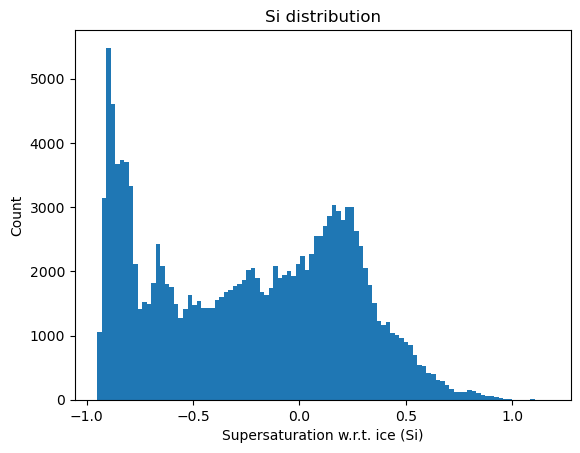

In [16]:
# add supersaturation WRT zero (>0 is supersaturated, <0 is subsaturated)
combined_df["Si"] = combined_df["%RH"] / 100.0 - 1.0

# plot distribution of Si
df = combined_df 
si = df["Si"].dropna()
plt.figure()
plt.hist(si, bins=100)
plt.xlabel("Supersaturation w.r.t. ice (Si)")
plt.ylabel("Count")
plt.title("Si distribution")
plt.show()

# CRYSTAL-FACE UND

Data Source: https://espoarchive.nasa.gov/archive/browse/crystalf/Citation (last access: 1/12/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-UND

In [18]:
import pandas as pd
from pathlib import Path
import re

def clean_col(name):
    name = name.strip()
    name = re.sub(r"[^\w]+", "_", name)
    return name.strip("_")

def read_mis_cit_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    # Number of header lines
    n_header = int(lines[0].split()[0])

    # Column names are two lines before data
    col_line = lines[n_header - 2]

    columns = [clean_col(c) for c in col_line.split()]

    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=n_header,
        names=columns,
        na_values=[999999.9999]
    )

    df["source_file"] = filepath.name
    return df
    
data_dir = Path('/home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-UND')

dfs = [
    read_mis_cit_file(f)
    for f in data_dir.glob("*MIS.CIT")
]

combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head()

,Time,COND_NUCL,FSSP_H2O,LIQ_H2O,ICE_DET,MixingRatio,RH,Ext_Coeff,source_file
0,53800.0,NaN,0.0,NaN,2.1240,11.3337,0.0410,1.7548,ND20020725__MIS.CIT
1,53801.0,NaN,0.0,NaN,2.1243,11.3337,0.0410,1.9484,ND20020725__MIS.CIT
2,53802.0,NaN,0.0,NaN,2.1242,11.3338,0.0409,2.1112,ND20020725__MIS.CIT
3,53803.0,NaN,0.0,NaN,2.1241,11.3338,0.0409,2.2388,ND20020725__MIS.CIT
4,53804.0,NaN,0.0,NaN,2.1241,11.5782,0.0416,2.3490,ND20020725__MIS.CIT


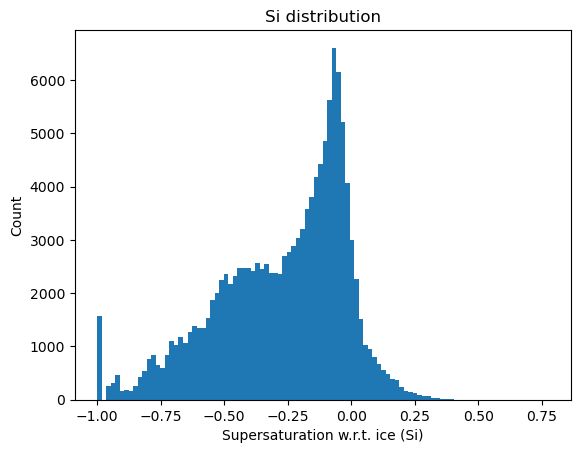

In [20]:
# add supersaturation WRT zero (>0 is supersaturated, <0 is subsaturated)
combined_df["Si"] = combined_df["RH"] / 100.0 - 1.0

# plot distribution of Si
df = combined_df 
si = df["Si"].dropna()
plt.figure()
plt.hist(si, bins=100)
plt.xlabel("Supersaturation w.r.t. ice (Si)")
plt.ylabel("Count")
plt.title("Si distribution")
plt.show()

# MC3E

Data Source: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmmc3e-1 (last access: 1/12/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/MC3E  
Note:
- Si is not pre-computed in files. Calculated from vapor mixing ratio, air temperature, and pressure. 

In [21]:
import pandas as pd
import re
from pathlib import Path

def clean_col(name):
    name = name.strip()
    name = re.sub(r"[^\w]+", "_", name)
    return name.strip("_")

def read_und_citation_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    # Number of header lines
    n_header = int(lines[0].split()[0])

    # Column names are two lines before data
    col_line = lines[n_header - 2]
    columns = [clean_col(c) for c in col_line.split()]

    # Read data
    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=n_header,
        names=columns,
        na_values=[
            999999.9999,
            999.9999999,
            9999.999999,
            99999.99999,
            99999999999,
            999999
        ]
    )

    df["source_file"] = filepath.name
    return df

data_dir = Path('/home/jko/ssl-cpi-analysis/data/env/MC3E')

dfs = [
    read_und_citation_file(f)
    for f in data_dir.iterdir()
    if f.is_file()
]

combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head()

,Time,Air_Temp,MachNo_N,IAS,TAS,Press_Alt,Pot_Temp_T1,Pitot_Wing,CABIN_PRES,STATIC_PR,...,2_DC_EffRad,IceMSOFreq,CPCConc,TSG_Date,source_file,GPS_Lat,GPS_Lon,GPS_Alt,GPS_GSpeed,GPS_GTrack
0,74969.25,29.0487,0.0482,16.0277,16.8035,389.5258,305.0867,1.4990,969.6332,967.2753,...,NaN,NaN,NaN,110527,2011_05_27_11_49_26_v2.mc3e,NaN,NaN,NaN,NaN,NaN
1,74970.25,29.0452,0.0483,16.0550,16.8322,389.6349,305.0844,1.4908,969.6029,967.2626,...,NaN,40050.0,NaN,110527,2011_05_27_11_49_26_v2.mc3e,NaN,NaN,NaN,NaN,NaN
2,74971.25,29.0395,0.0483,16.0548,16.8316,389.4712,305.0769,1.4908,969.6181,967.2816,...,NaN,39990.0,NaN,110527,2011_05_27_11_49_26_v2.mc3e,NaN,NaN,NaN,NaN,NaN
3,74972.25,29.0418,0.0486,16.1482,16.9296,389.5367,305.0799,1.5372,969.6567,967.2740,...,NaN,39990.0,NaN,110527,2011_05_27_11_49_26_v2.mc3e,NaN,NaN,NaN,NaN,NaN
4,74973.25,29.0485,0.0484,16.0880,16.8663,389.1329,305.0824,1.5443,969.5945,967.3208,...,NaN,39990.0,NaN,110527,2011_05_27_11_49_26_v2.mc3e,NaN,NaN,NaN,NaN,NaN


In [22]:
combined_df.columns

Index(['Time', 'Air_Temp', 'MachNo_N', 'IAS', 'TAS', 'Press_Alt',
       'Pot_Temp_T1', 'Pitot_Wing', 'CABIN_PRES', 'STATIC_PR', 'DEWPT',
       'MixingRatio', 'DewPoint', 'FrostPoint', 'POS_Roll', 'POS_Pitch',
       'POS_Head', 'POSZ_Acc', 'POS_Lat', 'POS_Lon', 'POS_Alt', 'POS_Spd',
       'POS_Trk', 'Alpha', 'Beta', 'VERT_VEL', 'Wind_Z', 'Wind_M', 'Wind_D',
       'TURB', 'King_LWC_ad', 'Nev_TWC', 'Nev_LWCcor', 'CDP_Conc', 'CDP_LWC',
       'CDP_MenD', 'CDP_VolDia', 'CDP_EffRad', '2_DC_Conc', '2_DC_MenD',
       '2_DC_VolDia', '2_DC_EffRad', 'IceMSOFreq', 'CPCConc', 'TSG_Date',
       'source_file', 'GPS_Lat', 'GPS_Lon', 'GPS_Alt', 'GPS_GSpeed',
       'GPS_GTrack'],
      dtype='object')

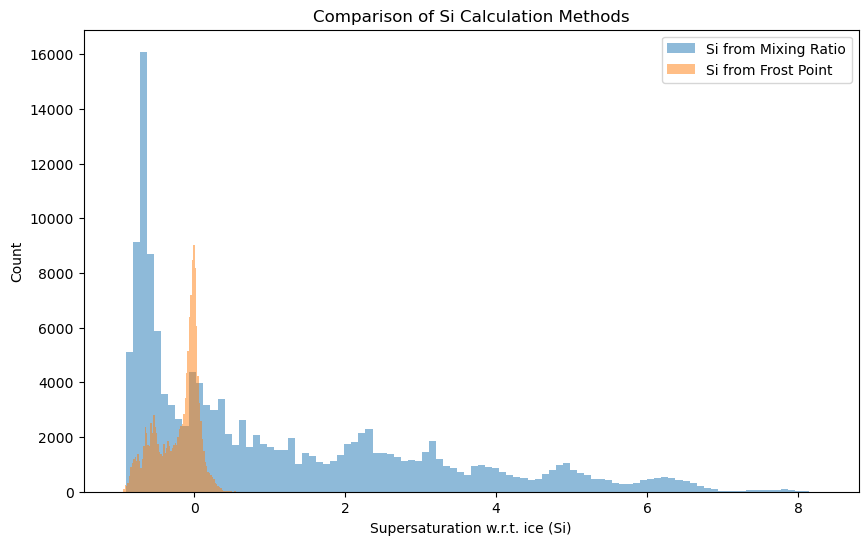

In [24]:
import numpy as np

def es_ice(T):
    """Saturation vapor pressure over ice [hPa]"""
    # T in °C
    T_K = T + 273.15
    return np.exp(9.550426 - 5723.265/T_K + 3.53068*np.log(T_K) - 0.007283*T_K)

# Convert MixingRatio g/kg -> g/g
w = combined_df["MixingRatio"] / 1000.0  # g/g
P = combined_df["STATIC_PR"]             # hPa
T = combined_df["Air_Temp"]              # °C

# Actual vapor pressure
e = w * P / (0.622 + w)

# Saturation vapor pressure over ice
e_si = es_ice(T)

# RH with respect to ice
combined_df["RH_ice"] = e / e_si * 100.0
combined_df["Si"] = combined_df["RH_ice"] / 100.0 - 1.0

# Alternative calculation from frost point
T_f = combined_df["FrostPoint"]  # Frost point in °C
T = combined_df["Air_Temp"]      # Ambient temperature in °C
combined_df["Si_2"] = es_ice(T_f) / es_ice(T) - 1.0

# Drop NaNs for both Si calculations
si1 = combined_df["Si"].dropna()
si2 = combined_df["Si_2"].dropna()

plt.figure(figsize=(10,6))

# Plot histogram for Si from mixing ratio
plt.hist(si1, bins=100, alpha=0.5, label='Si from Mixing Ratio')

# Plot histogram for Si from frost point
plt.hist(si2, bins=100, alpha=0.5, label='Si from Frost Point')

plt.xlabel("Supersaturation w.r.t. ice (Si)")
plt.ylabel("Count")
plt.title("Comparison of Si Calculation Methods")
plt.legend()
plt.show()

Notes:  
- Si derived from frost point vs. derived from vapor mixing ratio are very different 
- although they are both from laser hygrometer
- the derived Si from frost point variable looks more reasonable

# MidCix
Data Source: https://espoarchive.nasa.gov/archive/browse/midcix/WB57 (last access: 1/12/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/MidCix

In [25]:
import pandas as pd
import re
from pathlib import Path

def clean_col(name):
    """Clean column names for safe DataFrame usage."""
    name = name.strip()
    name = re.sub(r"[^\w]+", "_", name)
    return name.strip("_")

def parse_columns(header_line):
    """Parse column names, keeping units like '(s)' together."""
    tokens = header_line.split()
    cols = []
    i = 0
    while i < len(tokens):
        # Combine token with following if it looks like a unit
        if i + 1 < len(tokens) and re.match(r"^\(.*\)$", tokens[i + 1]):
            cols.append(f"{tokens[i]} {tokens[i+1]}")
            i += 2
        else:
            cols.append(tokens[i])
            i += 1
    return [clean_col(c) for c in cols]

def read_midcix_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    # Number of header lines from first line
    n_header = int(lines[0].split()[0])

    # The column line appears near the end of the header (here we pick last line before data)
    col_line = lines[n_header - 1]  # adjust if needed
    columns = parse_columns(col_line)

    # Read the data skipping header
    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=n_header,
        names=columns,
        na_values=[
            999999.9999,
            999.9999999,
            9999.999999,
            99999.99999,
            99999999999,
            999999
        ]
    )

    df["source_file"] = filepath.name
    return df

# Example usage
data_dir = Path('/home/jko/ssl-cpi-analysis/data/env/MidCix')
dfs = [read_midcix_file(f) for f in data_dir.iterdir() if f.is_file()]
combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head()

,UT_s,ppmv,P_mb,T_K,Ep_mb,Td_C,Esh_mb,Esi_mb,RH,g_kg,source_file
0,58834.8,346.95,599.5,268.07,0.20799,-35.70,4.18957,3.98641,5.22,0.2168,JW20040502.WB57
1,58835.8,342.52,598.6,268.11,0.20504,-35.83,4.20229,4.00006,5.13,0.2141,JW20040502.WB57
2,58836.8,339.98,597.8,268.16,0.20324,-35.91,4.21824,4.01721,5.06,0.2125,JW20040502.WB57
3,58837.8,337.49,597.0,268.18,0.20148,-35.99,4.22463,4.02408,5.01,0.2109,JW20040502.WB57
4,58839.8,329.64,595.5,268.19,0.19630,-36.23,4.22784,4.02752,4.87,0.2060,JW20040502.WB57


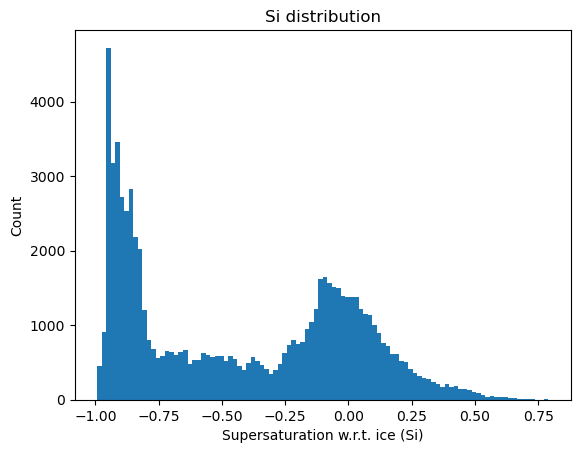

In [26]:
# add supersaturation WRT zero (>0 is supersaturated, <0 is subsaturated)
combined_df["Si"] = combined_df["RH"] / 100.0 - 1.0

# plot distribution of Si
df = combined_df 
si = df["Si"].dropna()
plt.figure()
plt.hist(si, bins=100)
plt.xlabel("Supersaturation w.r.t. ice (Si)")
plt.ylabel("Count")
plt.title("Si distribution")
plt.show()

# OLYMPEX
Data Source: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmolyx-1 (last access: 1/12/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/OLYMPEX

In [30]:
import pandas as pd
from pathlib import Path
import numpy as np

# Predefined OLYMPEX columns
olympex_cols = [
    "Time", "Air_Temp", "MachNo_N", "IAS", "TAS", "Press_Alt", "Pot_Temp_T1",
    "STATIC_PR", "DEWPT", "REL_HUM", "MixingRatio", "DewPoint", "FrostPoint",
    "RH", "IceMSOFreq", "TSG_Date", "POS_Roll", "POS_Pitch", "POS_Head",
    "POSZ_Acc", "POS_Lat", "POS_Lon", "POS_Alt", "POS_Spd", "POS_Trk",
    "Alpha", "Beta", "VERT_VEL", "Wind_Z", "Wind_M", "Wind_D", "TURB",
    "King_LWC_ad", "Nev_TWC", "Nev_LWCcor", "Nev_IWC", "CSI_M_Ratio",
    "CSI_CWC", "CDP_Conc", "CDP_LWC", "CDP_MenD", "CDP_VolDia", "CDP_EffRad",
    "2-DC_Conc", "2-DC_MenD", "2-DC_VolDia", "2-DC_EffRad", "Nt2DSHGT105",
    "Nt2DSH_all", "Nt2DSVGT105", "Nt2DSV_all", "Nt_HVPS3H", "Nt_HVPS3BV"
]

def read_und_olympex_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    # First line gives the number of header lines
    n_header = int(lines[0].split()[0])

    # Read data skipping header
    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=n_header,
        names=olympex_cols,
        na_values=[999999.9999, 999.9999999, 9999.999999, 99999.99999,
                   99999999999, 999999, 9.9999E+30, 9.999E+30]
    )

    df["source_file"] = filepath.name
    return df

# Directory containing OLYMPEX files
data_dir = Path("/home/jko/ssl-cpi-analysis/data/env/OLYMPEX")
dfs = [read_und_olympex_file(f) for f in data_dir.iterdir() if f.is_file()]
combined_df = pd.concat(dfs, ignore_index=True)

print(combined_df.head())

       Time  Air_Temp  MachNo_N      IAS      TAS  Press_Alt  Pot_Temp_T1  \
0  50537.42    8.6202    0.0427  25.1065  14.3814   289.2671     283.4896   
1  50538.42    8.5159    0.0519  26.3327  17.4542   290.1101     283.3928   
2  50539.42    8.4438    0.0608  29.2803  20.4582   291.4614     283.3334   
3  50540.42    8.3931    0.0717  31.4202  24.1251   291.6020     283.2837   
4  50541.42    8.2985    0.0821  32.3004  27.6152   292.1749     283.1941   

   STATIC_PR   DEWPT  REL_HUM  ...  2-DC_MenD  2-DC_VolDia  2-DC_EffRad  \
0   978.9437  6.4463  86.1619  ...        NaN          NaN          NaN   
1   978.8451  6.4450  86.9419  ...        NaN          NaN          NaN   
2   978.6871  6.4482  87.1580  ...        NaN          NaN          NaN   
3   978.6707  6.4087  87.1283  ...        NaN          NaN          NaN   
4   978.6037  6.3452  87.4355  ...        NaN          NaN          NaN   

    Nt2DSHGT105    Nt2DSH_all   Nt2DSVGT105    Nt2DSV_all     Nt_HVPS3H  \
0  9.999000

In [29]:
combined_df.columns

Index(['second', 'degC', 'None', 'm_s', 'm_s_1', 'm', 'decK', 'hPa', 'degC_1',
       '', 'ppmw', 'C', 'C_1', 'percent', 'Hz', 'stamp', 'degrees',
       'degrees_1', 'degrees_2', 'MPsec2', 'degrees_3', 'degrees_4', 'm_1',
       'MPsec', 'degrees_5', 'degrees_6', 'degrees_7', 'MPsec_1', 'MPsec_2',
       'MPsec_3', 'degrees_8', 'cm_2_3_s_1', 'g_m_3', 'g_m_3_1', 'g_m_3_2',
       'g_m_3_3', 'g_m_3_4', 'g_m_3_5', 'cm_3', 'g_m_3_6', 'um', 'um_1',
       'um_2', 'cm_3_1', 'um_3', 'um_4', 'um_5', 'm_3', 'm_3_1', 'm_3_2',
       'm_3_3', 'm_3_4', 'm_3_5', 'source_file'],
      dtype='object')

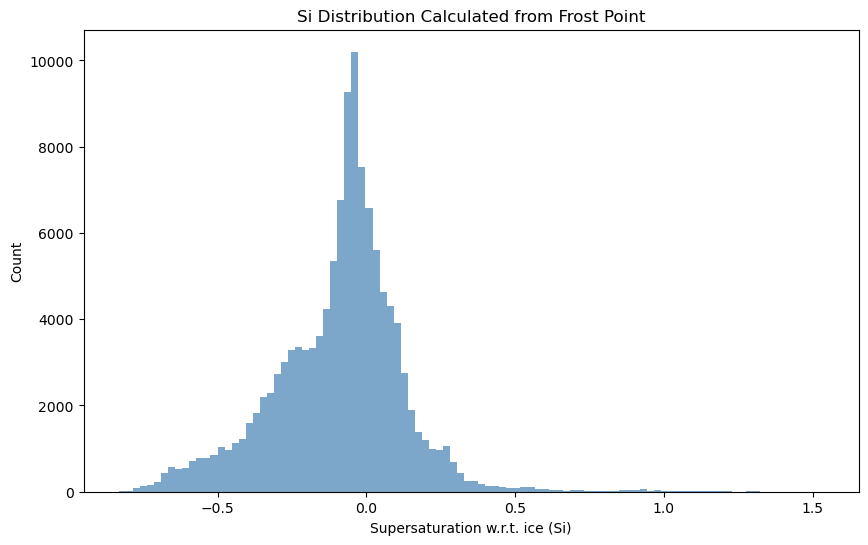

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def es_ice(T):
    """Saturation vapor pressure over ice [hPa]"""
    # T in °C
    T_K = T + 273.15
    return np.exp(9.550426 - 5723.265/T_K + 3.53068*np.log(T_K) - 0.007283*T_K)

# Ambient temperature
T = combined_df["Air_Temp"]

# Frost point temperature from laser hygrometer
T_f = combined_df["FrostPoint"]

# Supersaturation w.r.t. ice using frost point
combined_df["Si"] = es_ice(T_f) / es_ice(T) - 1.0

# Drop NaNs
si = combined_df["Si"].dropna()

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(si, bins=100, alpha=0.7, color='steelblue')
plt.xlabel("Supersaturation w.r.t. ice (Si)")
plt.ylabel("Count")
plt.title("Si Distribution Calculated from Frost Point")
plt.show()

# MPACE
Note: issues with water vapor measurements. No reliable RH data.

# AIRS-II

Data in netcdf files. Explore and identify relevant variables.

In [3]:
# Test the parser
filepath = Path("/home/jko/ssl-cpi-analysis/data/env/AIRS-II/RF01.20031105.175900_214123.PNI.nc")  # Replace with the actual file path
ds = xr.open_dataset(filepath, decode_timedelta=True)
out_filename = "variable_descriptions.txt"
out_dir = '/home/jko/ssl-cpi-analysis/data/env/AIRS-II'
out = Path(os.path.join(out_dir, out_filename))
with out.open("w", encoding="utf-8") as f:
    # global attrs
    f.write("Global Attributes:\n")
    for k, v in ds.attrs.items():
        f.write(f"{k}: {v}\n")
    f.write("\nVariables:\n")
    for name, var in ds.variables.items():
        f.write(f"{name}\n")
        # prefer a short human description if available
        desc = var.attrs.get("long_name") or var.attrs.get("description") or var.attrs.get("standard_name") or ""
        if desc:
            f.write(f"  description: {desc}\n")
        # write remaining attributes
        for ak, av in var.attrs.items():
            f.write(f"  {ak}: {av}\n")
        f.write("\n")
print(f"Wrote variable metadata to {out}")

Wrote variable metadata to /home/jko/ssl-cpi-analysis/data/env/AIRS-II/variable_descriptions.txt


In [4]:
ds

<xarray.Dataset> Size: 82MB
Dimensions:       (Time: 13344, sps1: 1, Vector32: 32, Vector64: 64,
                   Vector256: 256, Vector31: 31)
Coordinates:
  * Time          (Time) datetime64[ns] 107kB 2003-11-05T17:59:00 ... 2003-11...
Dimensions without coordinates: sps1, Vector32, Vector64, Vector256, Vector31
Data variables: (12/270)
    ADIFR         (Time) float32 53kB ...
    BDIFR         (Time) float32 53kB ...
    CNTEMP        (Time) float32 53kB ...
    CNTS          (Time) float32 53kB ...
    DPB           (Time) float32 53kB ...
    DPT           (Time) float32 53kB ...
    ...            ...
    WS            (Time) float32 53kB ...
    WSC           (Time) float32 53kB ...
    XICING        (Time) float32 53kB ...
    XICNC         (Time) float32 53kB ...
    XMACH2        (Time) float32 53kB ...
    ZERO          (Time) float32 53kB ...
Attributes: (12/14)
    Source:                         NCAR Research Aviation Facility
    Address:                        P.O. Box 3000, Boulder, CO 80307-3000
    Phone:                          (303) 497-1030
    Conventions:                    NCAR-RAF/nimbus
    Version:                        1.2
    DateProcessed:                  Jul 23 21:08 UTC 2004
    ...                             ...
    ProjectNumber:                  109
    FlightNumber:                   rf01
    FlightDate:                     11/05/2003
    TimeInterval:                   17:59:00-21:41:23
    Categories:                     Position,Thermodynamic,Aircraft State,Atm...
    SizeDistributionLegacyZeroBin:  Yes

Check distribution of TDL instrument measurements.

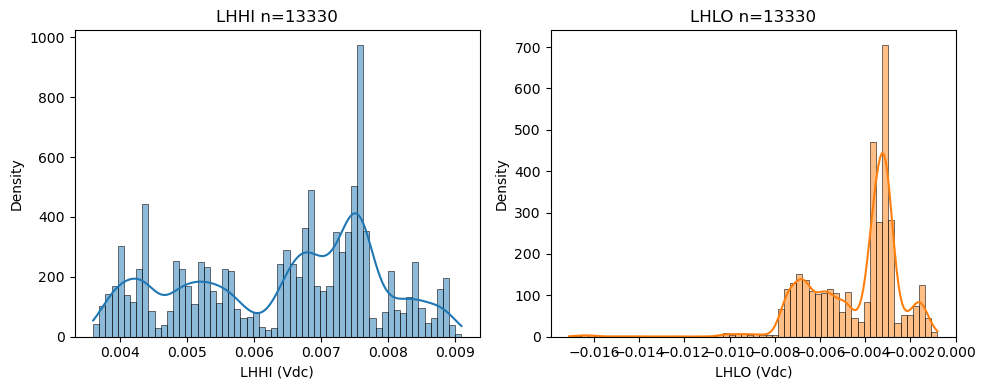

In [5]:
# Plot distribution of TDL measurements
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

for v in ("LHHI","LHLO"):
    if v not in ds.variables:
        raise KeyError(f"{v} not in ds")

a = ds["LHHI"].values.ravel().astype(float)
b = ds["LHLO"].values.ravel().astype(float)
a = a[np.isfinite(a)]
b = b[np.isfinite(b)]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(a, bins=60, kde=True, stat="density", color="C0")
plt.xlabel(f"LHHI ({ds['LHHI'].attrs.get('units','')})")
plt.title(f"LHHI n={a.size}")

plt.subplot(1,2,2)
sns.histplot(b, bins=60, kde=True, stat="density", color="C1")
plt.xlabel(f"LHLO ({ds['LHLO'].attrs.get('units','')})")
plt.title(f"LHLO n={b.size}")

plt.tight_layout()
plt.show()

Only raw voltages available. There doesn't seem to be a calibration coefficient in the netcdf file, or derived vapor concentration values.

There appears to be two relevant humidity variables: RHUM and DPXC.

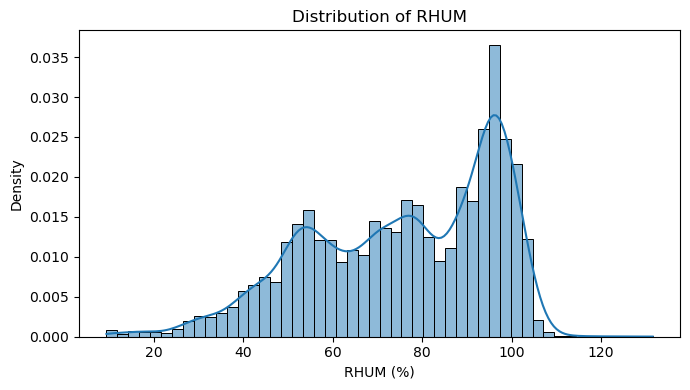

In [6]:
# Plot relative humidity (RHUM)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

da = ds["RHUM"]
arr = da.values.ravel()
arr = arr[~np.isnan(arr)]

plt.figure(figsize=(7,4))
sns.histplot(arr, bins=50, kde=True, stat="density", color="C0")
plt.xlabel(f"RHUM ({da.attrs.get('units','%')})")
plt.ylabel("Density")
plt.title("Distribution of RHUM")
plt.tight_layout()
plt.show()

Using DPXC and temperature var: ATX | samples = 13330


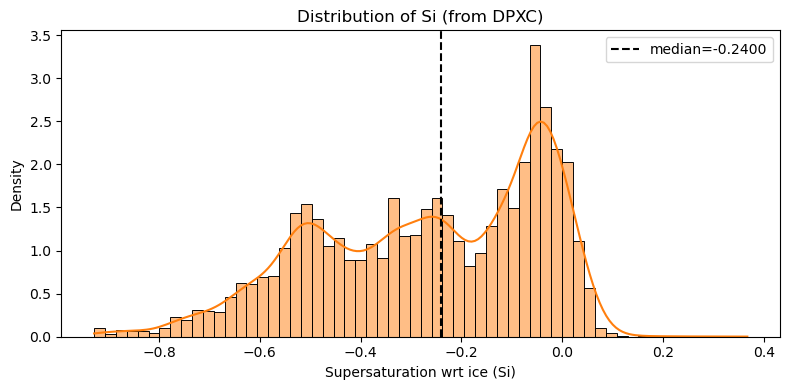

In [7]:
# Plot Si derived from frost point (DPXC)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def es_ice(T_C):
    T_K = np.asarray(T_C) + 273.15
    return np.exp(9.550426 - 5723.265 / T_K + 3.53068 * np.log(T_K) - 0.007283 * T_K)

def to_celsius(arr, varname):
    arr = np.asarray(arr, dtype=float)
    units = ds[varname].attrs.get("units", "").lower()
    if "k" in units or "kelvin" in units:
        return arr - 273.15
    return arr  # assume already in °C

if "DPXC" not in ds.variables:
    raise KeyError("DPXC not found in dataset")

frost = to_celsius(ds["DPXC"].values, "DPXC")

if 'ATX' not in ds.variables:
    raise KeyError('ATX not found in dataset')
temp_var = 'ATX'
temp = to_celsius(ds[temp_var].values, temp_var)

Si = es_ice(frost) / es_ice(temp) - 1.0
si_flat = Si.ravel()
si_clean = si_flat[np.isfinite(si_flat)]

print(f"Using DPXC and temperature var: {temp_var} | samples = {si_clean.size}")

plt.figure(figsize=(8,4))
sns.histplot(si_clean, bins=60, kde=True, stat="density", color="C1")
plt.xlabel("Supersaturation wrt ice (Si)")
plt.title("Distribution of Si (from DPXC)")
plt.axvline(np.nanmedian(si_clean), color="k", linestyle="--", label=f"median={np.nanmedian(si_clean):.4f}")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
len(si_flat)

13344

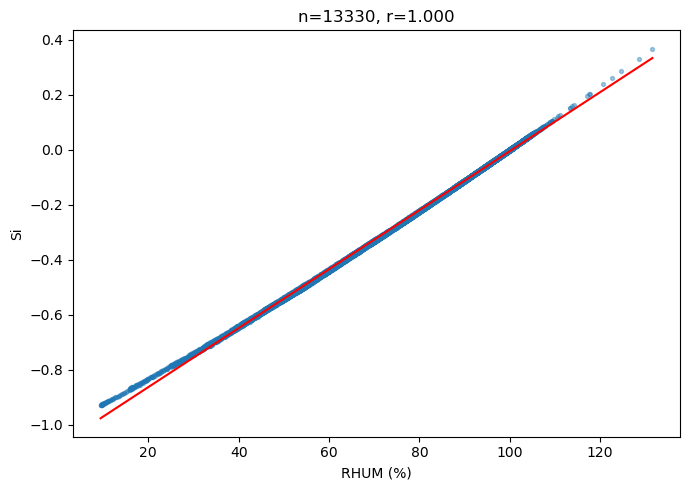

In [9]:
# plot RHUM versus derived Si
import numpy as np
import matplotlib.pyplot as plt

x = np.asarray(ds["RHUM"].values).ravel().astype(float)
y = np.asarray(si_flat).ravel().astype(float)

mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]
if x.size == 0:
    raise RuntimeError("No valid data to plot")

# subsample large arrays for stability
if x.size > 200_000:
    idx = np.random.default_rng(0).choice(x.size, 200_000, replace=False)
    x, y = x[idx], y[idx]

r = np.corrcoef(x, y)[0,1] if x.size > 1 else np.nan

m = b = np.nan
if x.size > 1 and np.nanstd(x) > 0 and np.nanstd(y) > 0 and np.unique(x).size > 1:
    try:
        m, b = np.polyfit(x, y, 1)
    except np.linalg.LinAlgError:
        m = b = np.nan

plt.figure(figsize=(7,5))
plt.scatter(x, y, s=8, alpha=0.4)
if np.isfinite(m):
    xs = np.array([x.min(), x.max()])
    plt.plot(xs, m*xs + b, color="red")
plt.xlabel("RHUM (%)")
plt.ylabel("Si")
plt.title(f"n={x.size}, r={r:.3f}")
plt.tight_layout()
plt.show()

Not perfect, but high correlation between RHUM and Si derived from frost point (DPXC).

RHUM attrs: {'units': '%', '_FillValue': None, 'missing_value': None, 'valid_min': None, 'valid_max': None}
total=315086, finite=313515, NaN=1571, inf=0

Top 10 value counts:
NaN          1571
74.839836       3
94.448586       3
89.718613       3
93.776978       3
38.679279       3
82.873756       3
94.329308       3
72.390610       3
69.134468       3
Name: count, dtype: int64

Physical-range count ([-20,200] %): 312792
count    312792.000000
mean         57.735191
std          32.662817
min           1.577700
25%          28.728318
50%          59.012302
75%          86.455153
max         199.934998
dtype: float64


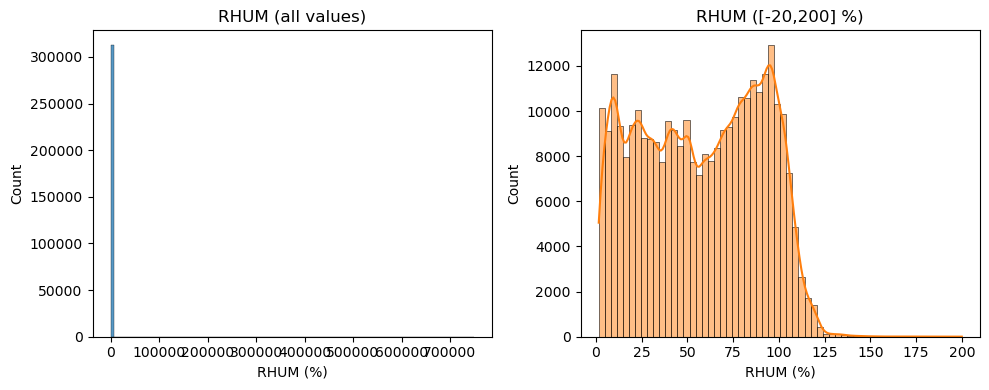

In [16]:
# Sequentially load NetCDF files and combine after loading
# Define the path to the files
path = Path("/home/jko/ssl-cpi-analysis/data/env/AIRS-II")
files = sorted(path.glob("*.nc"))

# Sequentially load files and combine
datasets = []
for file in files:
    with xr.open_dataset(file, decode_times=True, decode_timedelta=True) as ds:
        datasets.append(ds[["RHUM"]].load())  # Load only the RHUM variable

# Combine datasets along the time dimension
ds = xr.concat(datasets, dim="Time")

# Analyze the RHUM variable
var = ds["RHUM"]
print("RHUM attrs:", {k: var.attrs.get(k) for k in ("units", "_FillValue", "missing_value", "valid_min", "valid_max")})

arr = np.asarray(var.values).ravel().astype(float)
total = arr.size
n_nan = int(np.isnan(arr).sum())
n_inf = int(np.isinf(arr).sum())
n_finite = int(np.isfinite(arr).sum())
print(f"total={total}, finite={n_finite}, NaN={n_nan}, inf={n_inf}")

# Check common sentinel values (from attrs + common sentinels)
sentinels = []
for k in ("_FillValue", "missing_value"):
    v = var.attrs.get(k)
    if v is not None:
        try:
            sentinels.append(float(v))
        except Exception:
            pass
sentinels += [9.999e30, 9.999e20, 9999.0, 999.0, -9999.0]
for s in sorted(set(sentinels)):
    if np.isfinite(s) and abs(s) > 1e6:
        match = np.isclose(arr, s, atol=1e-6, rtol=0)
    else:
        match = (arr == s)
    cnt = int(np.count_nonzero(match))
    if cnt:
        print(f"sentinel {s} count={cnt}")

s = pd.Series(arr)
print("\nTop 10 value counts:")
print(s.value_counts(dropna=False).head(10))

# Physical-range diagnostics and summary
phys_mask = np.isfinite(arr) & (arr >= -20) & (arr <= 200)
print("\nPhysical-range count ([-20,200] %):", int(phys_mask.sum()))
if phys_mask.sum() > 0:
    print(pd.Series(arr[phys_mask]).describe())

# Plots: full and zoomed to realistic RH range
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(arr[~np.isnan(arr)], bins=100, color="C0")
plt.xlabel("RHUM (%)")
plt.title("RHUM (all values)")

plt.subplot(1, 2, 2)
sns.histplot(arr[phys_mask], bins=60, kde=True, color="C1")
plt.xlabel("RHUM (%)")
plt.title("RHUM ([-20,200] %)")

plt.tight_layout()
plt.show()

In [18]:
# Identify the invalid values 
# Define common sentinel values for invalid data
sentinels = [9.999e30, 9.999e20, 9999.0, 999.0, -9999.0, -999.0]

# Flatten the array for easier processing
arr = np.asarray(ds["RHUM"].values).ravel().astype(float)

# Check for NaNs and infinite values
n_nan = np.isnan(arr).sum()
n_inf = np.isinf(arr).sum()

# Check for sentinel values and count occurrences
sentinel_counts = {}
for sentinel in sentinels:
    count = np.sum(np.isclose(arr, sentinel, atol=1e-6)) if abs(sentinel) > 1e6 else np.sum(arr == sentinel)
    if count > 0:
        sentinel_counts[sentinel] = count

# Check for values outside the physical range
out_of_range_mask = (arr < -20) | (arr > 200)
out_of_range_values, out_of_range_counts = np.unique(arr[out_of_range_mask], return_counts=True)

# Print results
print("Invalid value counts:")
print(f"NaN: {n_nan}")
print(f"Inf: {n_inf}")
for sentinel, count in sentinel_counts.items():
    print(f"Sentinel {sentinel}: {count}")

print("\nValues outside physical range ([-20, 200]):")
for value, count in zip(out_of_range_values, out_of_range_counts):
    print(f"Value {value}: {count}")

Invalid value counts:
NaN: 1571
Inf: 0

Values outside physical range ([-20, 200]):
Value 200.26467895507812: 1
Value 201.2963104248047: 1
Value 202.30538940429688: 1
Value 204.3610076904297: 1
Value 204.6775665283203: 1
Value 206.75527954101562: 1
Value 207.00831604003906: 1
Value 207.6970977783203: 1
Value 208.75173950195312: 1
Value 208.94552612304688: 1
Value 210.09410095214844: 1
Value 211.2920379638672: 1
Value 212.15611267089844: 1
Value 213.26412963867188: 1
Value 213.59100341796875: 1
Value 213.99066162109375: 1
Value 214.60845947265625: 1
Value 215.73562622070312: 1
Value 216.50790405273438: 1
Value 217.2262420654297: 1
Value 217.47129821777344: 1
Value 219.31756591796875: 1
Value 220.86683654785156: 1
Value 221.370849609375: 1
Value 222.6242218017578: 1
Value 224.03318786621094: 1
Value 224.38621520996094: 1
Value 224.73805236816406: 1
Value 227.69122314453125: 1
Value 227.7891082763672: 1
Value 228.1657257080078: 1
Value 228.17303466796875: 1
Value 228.33287048339844: 1
Val

There seems to be some extreme outliers for RH. Probably best to define an upper relative humidity threshold. Choose 200% for now. 

# ATTREX

- Water vapor measurements from DLH-H2O and NOAA-H2O
- file format: *.ict files
- no temperature or pressure in these ict files
- for all *ict files, the TIME variable is the first variable in header line. Use this to parse data and to automate skipping the metadata header portion (which has variable length)
    - TIME variable name for DLH, NOAA, MMS respectively: [Time_UTC, NW_UTC_s,TIME_UTC]

In [21]:
# python
import re, json
from pathlib import Path
from collections import defaultdict, Counter

base_dir = Path("/home/jko/ssl-cpi-analysis/data/env/ATTREX")
files = list(base_dir.rglob("*.ict"))

rev_decl_re = re.compile(r'REVISION\s*[:\-]?\s*(R\d+)', re.I)
rmsg_re = re.compile(r'^\s*(R\d+)\s*:\s*(.+)$', re.I | re.M)

# only infer instrument from subfolders DLH-H2O or NOAA-H2O
def instrument_from_path(p: Path):
    parts = [pp.upper() for pp in p.parts]
    if "DLH-H2O" in parts: return "DLH-H2O"
    if "NOAA-H2O" in parts: return "NOAA-H2O"
    if "MMS" in parts: return "MMS"
    return None

counts = defaultdict(Counter)                       # counts[instrument][rev] -> int
rev_messages = defaultdict(lambda: defaultdict(lambda: defaultdict(set)))  # rev_messages[campaign][instrument][rev] -> set(msgs)

for p in files:
    inst = instrument_from_path(p)
    if inst is None:
        continue
    try:
        txt = p.read_text(errors="replace")
    except Exception:
        continue
    # campaign = first path component under base_dir
    try:
        campaign = p.relative_to(base_dir).parts[0]
    except Exception:
        campaign = p.parent.name

    declared = rev_decl_re.search(txt)
    declared_rev = declared.group(1) if declared else None

    found = {}
    for m in rmsg_re.finditer(txt):
        rv, msg = m.group(1), m.group(2).strip()
        found.setdefault(rv, []).append(msg)

    # record messages
    for rv, msgs in found.items():
        for msg in msgs:
            rev_messages[campaign][inst][rv].add(msg)

    # choose revision label for file
    if declared_rev:
        rev_label = declared_rev
    elif found:
        rev_label = max(found.keys(), key=lambda s: int(s.lstrip("R")))
    else:
        rev_label = "UNKNOWN"

    counts[inst][rev_label] += 1

# (1) print aggregated summary per instrument
for inst in sorted(counts):
    print(inst)
    for rev, cnt in counts[inst].most_common():
        print(f"  {rev}: {cnt}")
    print()

# (2) convert sets->lists and save nested dict per campaign/instrument/rev
out = {camp: {inst: {rv: sorted(list(msgs)) for rv, msgs in revs.items()} 
              for inst, revs in insts.items()} for camp, insts in rev_messages.items()}
out_path = base_dir / "ict_revision_messages.json"
out_path.write_text(json.dumps(out, indent=2))

DLH-H2O
  R2: 7
  R3: 6
  R0: 4

MMS
  R2: 7
  R4: 1
  R0: 1
  R3: 1

NOAA-H2O
  R2: 13
  R1: 1



1168

In [ ]:
this_dir = 'pwd/home/jko/ssl-cpi-analysis/data/env/ATTREX/DLH-H2O'


In [11]:
sample_file = '/home/jko/ssl-cpi-analysis/data/env/ATTREX/NOAA-H2O/NOAA-H2O_GHawk_20130226_R2.ict'
# Define parameters for DLH-H2O files
dlh_skip_metadata = 33  # Number of metadata lines to skip
dlh_column_names = ["Time_UTC", "H2O_ppmv"]  # Column names
dlh_na_values = ["-999", "-7777", "-8888"]  # Missing value flags

# Define parameters for NOAA-H2O files
noaa_skip_metadata = 35  # Number of metadata lines to skip
noaa_column_names = ["NW_UTC_s", "NW_WV_H2O_ppm", "NW_eTW_H2O_ppm"]  # Column names
noaa_na_values = ["-9999.99", "-7777.77", "-8888.88"]  # Missing value flags

df = pd.read_csv(
    sample_file,
    sep=r'\s*,\s*',         # comma-separated with optional spaces
    skiprows=noaa_skip_metadata,  # Skip metadata lines
    names=noaa_column_names,  # Use provided column names
    na_values=noaa_na_values,  # Handle missing values
    on_bad_lines='skip'  # Skip rows with inconsistent columns
)
df.head()

/tmp/tmp.TQ29pjUFEY/ipykernel_3381131/3190211160.py:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(


,,,NW_UTC_s,NW_WV_H2O_ppm,NW_eTW_H2O_ppm
PROJECT_INFO: ATTREX Deployment 2,NASA Global Hawk,Edwards AFB,CA,USA,January-March 2014
STIPULATIONS_ON_USE: Please contact the PIs to discuss applications and uncertainties,NaN,NaN,None,None,None
OTHER_COMMENTS: N/A,NaN,NaN,None,None,None
REVISION: R2,NaN,NaN,None,None,None
R0: Preliminary WV and eTW data using recent field calibration,NaN,NaN,None,None,None


In [ ]:
data_dir = '/home/jko/ssl-cpi-analysis/data/env/ATTREX'
instruments = ['DLH-H2O', 'NOAA-H2O']
for i in instruments:
    current_dir = os.path.join(data_dir, i)
    # load and combine all .ict files


Temp and Pressure are in separate MMS files. QA/QC here.

In [32]:
# load data
data_dir = Path('/home/jko/ssl-cpi-analysis/data/env/ATTREX/MMS')
files = sorted(data_dir.glob('*.ict'))

# Manually set scales here (adjust as needed)
scale_P = 0.01  # multiply raw P by this factor
scale_T = 0.01  # multiply raw T by this factor

def find_second_time_utc(p: Path):
    lines = p.read_text(errors='replace').splitlines()
    cnt = 0
    for i, ln in enumerate(lines):
        if re.search(r'\bTIME_UTC\b', ln, re.I):
            cnt += 1
            if cnt == 2:
                return i
    return None

na_vals = ["-999", "-9999.99", "-7777.77", "-8888.88", "n/a"]
dfs = []

for p in files:
    idx = find_second_time_utc(p)
    if idx is None:
        continue
    try:
        df = pd.read_csv(p, sep=r'\s*,\s*', skiprows=idx, header=0, engine='python', na_values=na_vals)
    except Exception:
        df = pd.read_csv(p, sep=r'\s+', skiprows=idx, header=0, engine='python', na_values=na_vals)
    if df.empty:
        continue
    # apply manual scaling for P and T if present
    if "P" in df.columns:
        df["P"] = pd.to_numeric(df["P"], errors="coerce") * scale_P
    if "T" in df.columns:
        df["T"] = pd.to_numeric(df["T"], errors="coerce") * scale_T
    df['source_file'] = p.name
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# choose thresholds
T_min, T_max = 140.0, 330.0   # permissive; use 170.0 for strict lower bound
P_min, P_max = 1.0, 1100.0    # use 10.0 for stricter lower bound

def filter_phys(df):
    before = len(df)
    mask_valid = pd.to_numeric(df["T"], errors="coerce").between(T_min, T_max) & \
                 pd.to_numeric(df["P"], errors="coerce").between(P_min, P_max)
    # also exclude common sentinel values if present
    sentinels = {-999, -9999, -9999.99, -7777, -7777.77, -8888, -8888.88, -99999}
    mask_sentinels = (~df["T"].isin(sentinels)) & (~df["P"].isin(sentinels))
    final_mask = mask_valid & mask_sentinels
    out = df[final_mask].copy()
    removed = before - len(out)
    print(f"rows before={before}, after={len(out)}, removed={removed}")
    print("T range kept:", out["T"].min(), out["T"].max())
    print("P range kept:", out["P"].min(), out["P"].max())
    return out

clean = filter_phys(combined)

print(f"Files read: {len(dfs)}  Combined rows: {len(clean)}")
clean.head()

rows before=581370, after=579628, removed=1742
T range kept: 184.3 298.65000000000003
P range kept: 66.39 993.12
Files read: 10  Combined rows: 579628


,TIME_UTC,P,T,TAS,U,V,W,TEDR,REYN,G_LAT,G_LONG,G_ALT,POT,ROLL,HDG,PITCH,source_file
0,68031.9,906.69,279.49,8036,-30.0,-299.0,-99999.0,-824.0,530.0,3490691,-11789735,9238,28742,-2044.0,22550,1332.0,MMS-1HZ_GHawk_20131220_R2.ict
1,68032.9,904.75,279.32,8032,7.0,-392.0,-99999.0,-748.0,539.0,3490637,-11789795,9409,28743,-2068.0,22216,1378.0,MMS-1HZ_GHawk_20131220_R2.ict
2,68033.9,902.86,279.32,7999,73.0,-519.0,-99999.0,-690.0,554.0,3490580,-11789852,9580,28759,-2049.0,21909,1391.0,MMS-1HZ_GHawk_20131220_R2.ict
3,68034.9,900.93,279.17,7977,37.0,-536.0,-99999.0,-568.0,553.0,3490521,-11789905,9754,28762,-1976.0,21685,1418.0,MMS-1HZ_GHawk_20131220_R2.ict
4,68035.9,898.98,278.98,8045,-11.0,-417.0,-99999.0,-587.0,540.0,3490460,-11789956,9930,28760,-1934.0,21487,1468.0,MMS-1HZ_GHawk_20131220_R2.ict


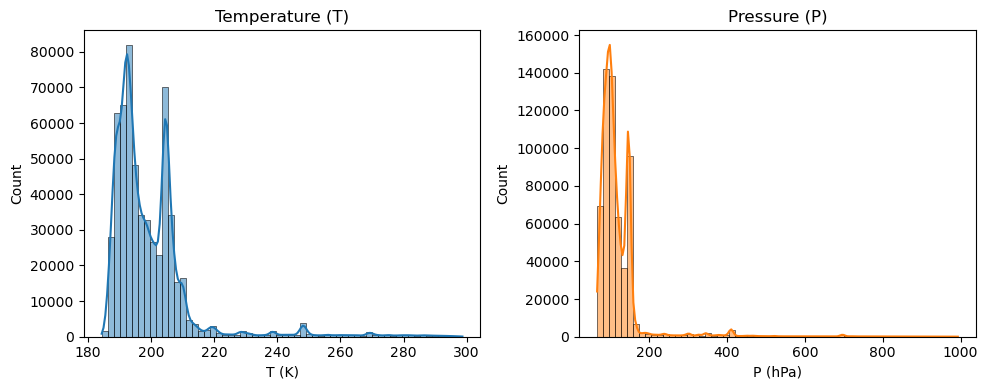

In [33]:
# plot distributions of temperature and pressure 
df = clean
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["T"].dropna(), bins=60, kde=True, ax=axes[0], color="C0")
axes[0].set_title("Temperature (T)")
axes[0].set_xlabel("T (K)")
sns.histplot(df["P"].dropna(), bins=60, kde=True, ax=axes[1], color="C1")
axes[1].set_title("Pressure (P)")
axes[1].set_xlabel("P (hPa)")
plt.tight_layout()
plt.show()

# ESCAPE

- atmospheric state filename format: atmospheric-state_*.nc
- learjet filename format: ESCAPE-Page0_Learjet_*.ict

In [3]:
# Check atmospheric state data
# python
from pathlib import Path
import xarray as xr

data_dir = Path('/home/jko/ssl-cpi-analysis/data/env/ESCAPE/atmospheric-and-aircraft-state/jk4731581324')
files = sorted(data_dir.glob('atmospheric-state_*.nc'))
if not files:
    raise SystemExit(f"No files matching atmospheric-state_*.nc in {data_dir}")

# lazy-open and combine by coordinates
ds = xr.open_mfdataset(files, combine='by_coords', parallel=True, engine='netcdf4', decode_times=True)
ds = ds.load()
ds


<xarray.Dataset> Size: 34MB
Dimensions:    (time: 204326, sps1: 1)
Coordinates:
  * time       (time) datetime64[ns] 2MB 2022-05-31T14:10:01 ... 2022-06-17T1...
  * sps1       (sps1) int64 8B 0
Data variables: (12/20)
    lat        (time, sps1) float64 2MB 29.61 29.61 29.61 ... 29.64 29.64 29.64
    lon        (time, sps1) float64 2MB -95.66 -95.66 -95.66 ... -95.69 -95.69
    alt        (time, sps1) float64 2MB 136.3 140.2 146.0 ... 317.0 316.7 316.4
    vel-ns     (time, sps1) float64 2MB -57.55 -57.74 -57.5 ... 67.03 66.82
    vel-ew     (time, sps1) float64 2MB 2.345 2.146 1.943 ... -3.693 -1.62
    vel-v      (time, sps1) float64 2MB -3.115 -4.805 -6.778 ... 0.2764 0.3386
    ...         ...
    mso-port   (time, sps1) float64 2MB 4e+04 4e+04 4e+04 ... 4e+04 4e+04 4e+04
    mso-stbd   (time, sps1) float64 2MB 4.001e+04 4.001e+04 ... 4.001e+04
    TAS        (time, sps1) float64 2MB 67.1 67.02 67.69 ... 64.06 64.13 63.51
    wspd       (time, sps1) float64 2MB 9.565 9.396 9.904 ... 2.909 3.159 3.321
    wdir       (time, sps1) float64 2MB 168.1 157.4 161.1 ... 181.0 199.1 192.1
    wind_v     (time, sps1) float64 2MB -0.8526 -0.7097 -0.4515 ... 0.367 0.7546
Attributes: (12/21)
    Institution:            National Research Council of Canada (NRC)
    Address:                Flight Research Laboratory, NRC, Bldg. U-61, 1920...
    Project:                ESCAPE
    NRCProjectManager:      Dr. Keyvan Ranjbar
    NRCDataAuthors:         Mr. Kenny Bala, Dr. Mengistu Wolde
    PointOfContact:         Keyvan.Ranjbar@nrc-cnrc.gc.ca
    ...                     ...
    GeospatialLonMax:       -93.912889
    CenterCoordLat:         29.729370
    CenterCoordLon:         -94.264249
    time_coverage_start:    2022-05-31T14:10:01
    time_coverage_end:      2022-05-31T18:34:59
    TimeInterval:           14:10:01-18:34:59

Variables relevant to water vapor: H2O_L840a, H2O_L7000, Td_CM

In [8]:
files

[PosixPath('/home/jko/ssl-cpi-analysis/data/env/ESCAPE/learjet-state-measurements/jk4731582465/RF01_ict_20220602a/ESCAPE-Page0_Learjet_20220602_R0.ict'),
 PosixPath('/home/jko/ssl-cpi-analysis/data/env/ESCAPE/learjet-state-measurements/jk4731582465/RF03_ict_20220604/ESCAPE-Page0_Learjet_20220604_R0.ict'),
 PosixPath('/home/jko/ssl-cpi-analysis/data/env/ESCAPE/learjet-state-measurements/jk4731582465/RF04_ict_20220608/ESCAPE-Page0_Learjet_20220608_R0.ict'),
 PosixPath('/home/jko/ssl-cpi-analysis/data/env/ESCAPE/learjet-state-measurements/jk4731582465/RF06_ict_20220610/ESCAPE-Page0_Learjet_20220610_R0.ict'),
 PosixPath('/home/jko/ssl-cpi-analysis/data/env/ESCAPE/learjet-state-measurements/jk4731582465/RF07_ict_20220611/ESCAPE-Page0_Learjet_20220611_R0.ict'),
 PosixPath('/home/jko/ssl-cpi-analysis/data/env/ESCAPE/learjet-state-measurements/jk4731582465/RF09_ict_20220616b/ESCAPE-Page0_Learjet_20220616_R0.ict'),
 PosixPath('/home/jko/ssl-cpi-analysis/data/env/ESCAPE/learjet-state-measurement

In [11]:
# python
import pandas as pd
from pathlib import Path
from io import StringIO

data_dir = Path('/home/jko/ssl-cpi-analysis/data/env/ESCAPE/learjet-state-measurements/jk4731582465')
pattern = "ESCAPE-Page0_Learjet_*.ict"
files = sorted(data_dir.rglob(pattern))

def find_data_header(p: Path):
    """
    Find the actual data header row by looking for the LAST occurrence of 'Time_Start,'
    followed by multiple comma-separated column names (at least 20 columns).
    """
    lines = p.read_text(errors='replace').splitlines()
    candidates = []
    for i, ln in enumerate(lines):
        if 'Time_Start,' in ln:
            # count commas to estimate column count
            col_count = ln.count(',') + 1
            candidates.append((i, col_count))
    # pick the candidate with most columns (likely the real header)
    if candidates:
        best_idx = max(candidates, key=lambda x: x[1])[0]
        return best_idx
    return None

na_vals = ["-999", "-9999.99", "-7777.77", "-8888.88", "n/a"]
dfs = []

for p in files:
    idx = find_data_header(p)
    if idx is None:
        print(f"skip (no data header): {p.name}")
        continue
    txt = p.read_text(errors='replace')
    lines = txt.splitlines()
    data_text = "\n".join(lines[idx:])  # from header onward
    try:
        df = pd.read_csv(StringIO(data_text), sep=",", header=0, engine="python",
                         na_values=na_vals, on_bad_lines="skip")
    except Exception as e:
        print(f"read error {p.name}: {e}")
        continue
    if df.empty:
        continue
    df["source_file"] = p.name
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print(f"files found: {len(files)}  files read: {len(dfs)}  combined rows: {len(combined_df)}")
combined_df.head()

files found: 7  files read: 7  combined rows: 67380


,Time_Start,TAS,Palt,Hdg,Temp,Dew,NevLWC,FSSPWC,FCDPHWC,FCDPWC,...,2DS10Hawk,2DS50Hawk,HVPS4H50,HVPS4H150,HVPS4V50,HVPS4V150,CPI,Lat,Long,source_file
0,57018.0,6.0,49.0,263.0,30.3,22.1,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,29.63,-95.66,ESCAPE-Page0_Learjet_20220602_R0.ict
1,57019.0,6.0,49.0,263.0,30.3,22.1,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,29.63,-95.66,ESCAPE-Page0_Learjet_20220602_R0.ict
2,57020.0,6.0,49.0,263.0,30.2,22.1,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,29.63,-95.66,ESCAPE-Page0_Learjet_20220602_R0.ict
3,57021.0,6.0,49.0,263.0,30.2,22.2,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,29.63,-95.66,ESCAPE-Page0_Learjet_20220602_R0.ict
4,57022.0,6.0,49.0,263.0,30.2,22.1,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,29.63,-95.66,ESCAPE-Page0_Learjet_20220602_R0.ict


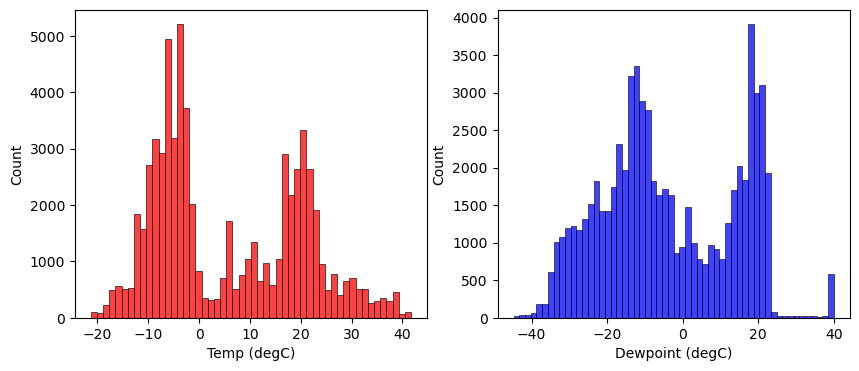

In [14]:
# Plot the distribution of temperature and Dewpoint
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(combined_df['Temp'].dropna(), ax=axes[0], color='red')
axes[0].set_xlabel('Temp (degC)')

sns.histplot(combined_df['Dew'].dropna(), ax=axes[1], color='blue')
axes[1].set_xlabel('Dewpoint (degC)')

plt.show()

# ICE-L
- data in netcdf files

In [4]:
file = '/home/jko/ssl-cpi-analysis/data/env/ICE-L/RF01.20071107.175400_222200.PNI.nc'
ds = xr.open_dataset(file, decode_timedelta=True)
ds

<xarray.Dataset> Size: 41MB
Dimensions:        (Time: 16081, sps1: 1, Vector64: 64, Vector31: 31,
                    Vector100: 100)
Coordinates:
  * Time           (Time) datetime64[ns] 129kB 2007-11-07T17:54:00 ... 2007-1...
    GGALT          (Time) float32 64kB ...
    LATC           (Time) float32 64kB ...
    LONC           (Time) float32 64kB ...
Dimensions without coordinates: sps1, Vector64, Vector31, Vector100
Data variables: (12/247)
    A1DC_LPC       (Time, sps1, Vector64) float32 4MB ...
    A2DTEMP_AFTL1  (Time) float32 64kB ...
    A2DTEMP_AFTL2  (Time) float32 64kB ...
    A2DTEMP_AFTR1  (Time) float32 64kB ...
    A2DTEMP_FWDL1  (Time) float32 64kB ...
    A2DTEMP_FWDL2  (Time) float32 64kB ...
    ...             ...
    LONDG          (Time) float32 64kB ...
    ALTDG          (Time) float32 64kB ...
    VEWDG          (Time) float32 64kB ...
    VNSDG          (Time) float32 64kB ...
    VSPDDG         (Time) float32 64kB ...
    ALTXDG         (Time) float32 64kB ...
Attributes: (12/23)
    Source:               NCAR Research Aviation Facility
    Address:              P.O. Box 3000, Boulder, CO 80307-3000
    Phone:                (303) 497-1030
    Conventions:          NCAR-RAF/nimbus
    ConventionsURL:       http://www.eol.ucar.edu/raf/Software/netCDF.html
    ConventionsVersion:   1.3
    ...                   ...
    TimeInterval:         17:54:00-22:22:00
    Categories:           Position,Thermodynamic,Aircraft State,Atmos. State,...
    DGPS_DateMerged:      2009-06-11 JAG
    TDL_DateMerged:       2009-06-11 JAG
    CO_DateMerged:        2009-06-11 JAG
    history:              Thu Jun 11 19:30:08 2009: ncatted -a history,global...

In [2]:
# load and combine nc files
data_dir = Path('/home/jko/ssl-cpi-analysis/data/env/ICE-L')
files = sorted(data_dir.glob('*.nc'))

# List to store individual datasets
datasets = []

# Load each file and append to the list
for file in files:
    try:
        ds = xr.open_dataset(file, decode_timedelta=True)
        # keep only vars that have Time dimension
        ds = ds.drop_vars([var for var in ds.data_vars if len(ds[var].dims) > 1])
        ds = ds.squeeze() # get rid of unused dimensions
        datasets.append(ds)
    except Exception as e:
        print(f"Error loading {file}: {e}")

In [3]:
# total size of all data
total_size = sum(ds.nbytes for ds in datasets)
print(f"Total size of datasets: {total_size / 1e6:.2f} MB")

Total size of datasets: 221.61 MB


In [4]:
# print the dimensions of each ds in datasets
for ds in datasets:
    print(ds.dims)

FrozenMappingWarningOnValuesAccess({'Time': 16081})
FrozenMappingWarningOnValuesAccess({'Time': 14501})
FrozenMappingWarningOnValuesAccess({'Time': 22201})
FrozenMappingWarningOnValuesAccess({'Time': 17861})
FrozenMappingWarningOnValuesAccess({'Time': 26791})
FrozenMappingWarningOnValuesAccess({'Time': 22131})
FrozenMappingWarningOnValuesAccess({'Time': 16741})
FrozenMappingWarningOnValuesAccess({'Time': 10011})
FrozenMappingWarningOnValuesAccess({'Time': 13051})
FrozenMappingWarningOnValuesAccess({'Time': 16741})
FrozenMappingWarningOnValuesAccess({'Time': 19680})
FrozenMappingWarningOnValuesAccess({'Time': 14771})


In [5]:
# print variables with more than Time dimensions
# Filter variables with more dimensions than just "Time"
variables_with_extra_dims = [var for var in ds.data_vars if len(ds[var].dims) > 1 and "Time" in ds[var].dims]

print("Variables with more dimensions than just 'Time':")
for var in variables_with_extra_dims:
    print(f"{var}: {ds[var].dims}")

Variables with more dimensions than just 'Time':


In [6]:
# Combine datasets along common dimensions
combined_ds = xr.concat(datasets, dim="Time")
combined_ds

<xarray.Dataset> Size: 238MB
Dimensions:         (Time: 210561)
Coordinates:
  * Time            (Time) datetime64[ns] 2MB 2007-11-07T17:54:00 ... 2007-12...
    GGALT           (Time) float32 842kB 1.707e+03 1.707e+03 ... 1.722e+03
    LATC            (Time) float32 842kB 39.91 39.91 39.91 ... 39.91 39.91 39.91
    LONC            (Time) float32 842kB -105.1 -105.1 -105.1 ... -105.1 -105.1
Data variables: (12/277)
    A2DTEMP_AFTL1   (Time) float32 842kB 66.0 66.0 66.0 66.0 ... 60.0 60.0 60.0
    A2DTEMP_AFTL2   (Time) float32 842kB 66.0 66.0 66.0 66.0 ... 60.0 60.0 60.0
    A2DTEMP_AFTR1   (Time) float32 842kB 60.0 60.0 60.0 60.0 ... 56.0 56.0 56.0
    A2DTEMP_FWDL1   (Time) float32 842kB 64.0 64.0 64.0 64.0 ... 58.0 58.0 58.0
    A2DTEMP_FWDL2   (Time) float32 842kB 64.0 64.0 64.0 64.0 ... 58.0 58.0 58.0
    A2DTEMP_VID     (Time) float32 842kB 66.0 66.0 66.0 66.0 ... 62.0 62.0 62.0
    ...              ...
    Clock322        (Time) float32 842kB nan nan nan nan nan ... nan nan nan nan
    Clock323        (Time) float32 842kB nan nan nan nan nan ... nan nan nan nan
    Clock324        (Time) float32 842kB nan nan nan nan nan ... nan nan nan nan
    Clock325        (Time) float32 842kB nan nan nan nan nan ... nan nan nan nan
    CONC1DC100_LPC  (Time) float32 842kB nan nan nan nan nan ... nan nan nan nan
    CONC1DC150_LPC  (Time) float32 842kB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/23)
    Source:               NCAR Research Aviation Facility
    Address:              P.O. Box 3000, Boulder, CO 80307-3000
    Phone:                (303) 497-1030
    Conventions:          NCAR-RAF/nimbus
    ConventionsURL:       http://www.eol.ucar.edu/raf/Software/netCDF.html
    ConventionsVersion:   1.3
    ...                   ...
    TimeInterval:         17:54:00-22:22:00
    Categories:           Position,Thermodynamic,Aircraft State,Atmos. State,...
    DGPS_DateMerged:      2009-06-11 JAG
    TDL_DateMerged:       2009-06-11 JAG
    CO_DateMerged:        2009-06-11 JAG
    history:              Thu Jun 11 19:30:08 2009: ncatted -a history,global...

In [7]:
datasets[0]['Time'].size

16081

In [8]:
# Timestep sumcheck
running_sum = 0
for ds in datasets:
    running_sum += ds['Time'].size
print(f'running sum: {running_sum}')
print(f'combined_ds size: {combined_ds['Time'].size}')

running sum: 210561
combined_ds size: 210561


In [9]:
# Find relevant variables
# Define keywords for each category
categories = {
    "temperature": ["temp", "temperature", 'atx'],
    "pressure": ["press", "pressure", 'psxc', 'psf', 'psfd'],
    "humidity": ["humidity", "rh", "relative_humidity", 'rhx', 'rhi'],
    "water_vapor": ["h2o", "water_vapor", "wv", 'vxl', 'dpxc', 'rhodt', 'mr', 'ewx'],
    "position": ["lat", "lon", "latitude", "longitude"],
    "altitude": ["alt", "altitude", "height"]
}

# Find variables matching the keywords
related_vars = {key: [] for key in categories}
for var in combined_ds.data_vars:
    var_lower = var.lower()
    for category, keywords in categories.items():
        if any(keyword in var_lower for keyword in keywords):
            related_vars[category].append(var)

# Print the results
for category, vars in related_vars.items():
    print(f"{category.capitalize()} variables: {vars}\n")

Temperature variables: ['A2DTEMP_AFTL1', 'A2DTEMP_AFTL2', 'A2DTEMP_AFTR1', 'A2DTEMP_FWDL1', 'A2DTEMP_FWDL2', 'A2DTEMP_VID', 'CNTEMP', 'INTEMP', 'UTEMP_RWI', 'ATX']

Pressure variables: ['PSFD', 'PSFRD', 'UPRESS_RWI', 'PSFC', 'PSFDC', 'PSXC']

Humidity variables: ['INRHUM', 'XRHGNI', 'RHODT', 'RHUM']

Water_vapor variables: ['CO2MR_NCNDIR', 'COMR_AL', 'DPXC', 'MR', 'MRTDLL_MC', 'MRTDLS_MC', 'RHODT']

Position variables: ['BLATA', 'BLONGA', 'GGLAT', 'GGLON', 'LAT', 'LON', 'LATDG', 'LONDG']

Altitude variables: ['ALT', 'PALT', 'PALTF', 'ALTDG', 'ALTXDG']



In [10]:
# print attributes of potentially relevant variables into text file
file_dir = '/home/jko/ssl-cpi-analysis/data/env/ICE-L'
filename = 'relevant_vars_attrs.txt'
filepath = os.path.join(file_dir, filename)
# Write relevant attributes to a text file
with open(filepath, 'w') as f:
    for category, vars in related_vars.items():
        f.write(f"\n ===== {category.capitalize()} variables: ==== \n")
        for v in vars:
            f.write(f"\nVariable: {v}\n")
            f.write("Attributes:\n")
            for attr, value in combined_ds[v].attrs.items():
                f.write(f"  {attr}: {value}\n")
print(f"Attributes written to {filepath}")

Attributes written to /home/jko/ssl-cpi-analysis/data/env/ICE-L/relevant_vars_attrs.txt


Variables to likely use:
- Temp: ATX
- Pressure: PSXC
- Humidity: RHUM
- Dew Point: DPXC
- Laser-based Water Vapor: MRTDLL_MC (long path)

In [11]:
variables = ['ATX', 'PSXC', 'RHUM', 'DPXC', 'MRTDLL_MC']
for v in variables:
    print(f'=== {v} ===')
    print(combined_ds[v].attrs) 

=== ATX ===
{'units': 'deg_C', 'long_name': 'Ambient Temperature, Reference', 'Category': 'Atmos. State', 'standard_name': 'air_temperature', 'DataQuality': 'Good', 'Dependencies': '1 ATRR'}
=== PSXC ===
{'units': 'hPa', 'long_name': 'Corrected Static Pressure, Reference', 'Category': 'Atmos. State', 'standard_name': 'air_pressure', 'DataQuality': 'Good', 'Dependencies': '1 PSFDC'}
=== RHUM ===
{'units': '%', 'long_name': 'Relative Humidity', 'Category': 'Atmos. State', 'standard_name': 'relative_humidity', 'DataQuality': 'Good', 'Dependencies': '3 ATX PSXC EDPC'}
=== DPXC ===
{'units': 'deg_C', 'long_name': 'Dew Point Temperature, Reference', 'Category': 'Atmos. State', 'standard_name': 'dew_point_temperature', 'DataQuality': 'Good', 'Dependencies': '1 DPBC'}
=== MRTDLL_MC ===
{'units': 'gram/kg', 'long_name': 'Mixing Ratio, TDL Long Absorption Path', 'Category': 'Atmos. State', 'standard_name': 'humidity_mixing_ratio', 'DataQuality': 'Good', 'Dependencies': '1 MRTDLS_MC'}


In [12]:
# Check for invalid data 

# List of variables to check
variables = ['ATX', 'PSXC', 'RHUM', 'DPXC', 'MRTDLL_MC']

# Define invalid values (e.g., missing values or known invalid flags)
invalid_values = [-999, -9999, -9999.99, -7777.77, -8888.88, -8888, -7777]

# Initialize a list to store the summary
summary = []

# Perform data quality check
for var in variables:
    if var in combined_ds:
        data = combined_ds[var].values
        total_count = data.size
        invalid_count = np.isin(data, invalid_values).sum() + np.isnan(data).sum()
        valid_count = total_count - invalid_count
        valid_percentage = (valid_count / total_count) * 100
        invalid_percentage = (invalid_count / total_count) * 100

        # Append results to the summary list
        summary.append({
            "Variable": var,
            "Total Values": total_count,
            "Valid Values": valid_count,
            "Invalid Values": invalid_count,
            "Valid (%)": f"{valid_percentage:.2f}%",
            "Invalid (%)": f"{invalid_percentage:.2f}%"
        })
    else:
        print(f"Variable {var} not found in ds_combined.")

# Create a DataFrame for the summary
summary_df = pd.DataFrame(summary)

# Display the summary table
print(summary_df)

    Variable  Total Values  Valid Values  Invalid Values Valid (%) Invalid (%)
0        ATX        210561        210525              36    99.98%       0.02%
1       PSXC        210561        210525              36    99.98%       0.02%
2       RHUM        210561        209641             920    99.56%       0.44%
3       DPXC        210561        209651             910    99.57%       0.43%
4  MRTDLL_MC        210561        199923           10638    94.95%       5.05%


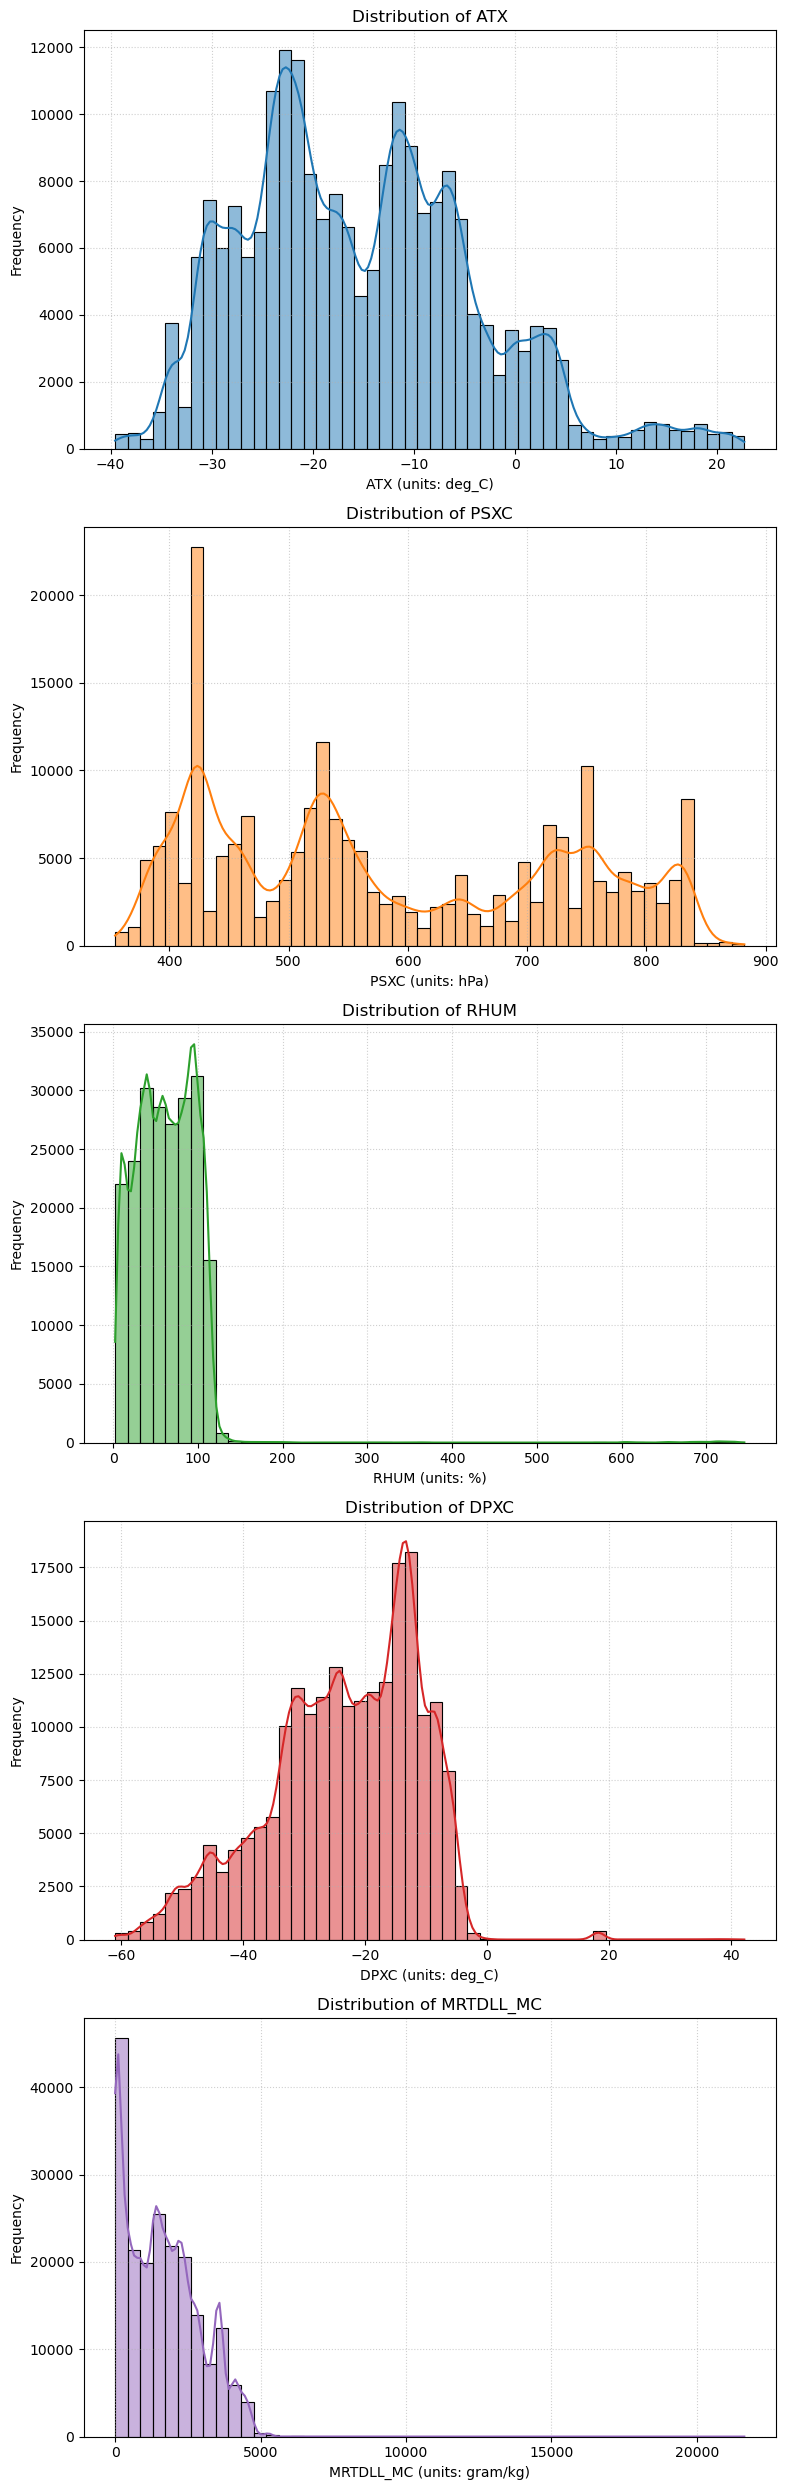

In [13]:
# Plot distributions

# List of variables to check
variables = ['ATX', 'PSXC', 'RHUM', 'DPXC', 'MRTDLL_MC']

# Define invalid values
invalid_values = [-999, -9999, -9999.99, -7777.77, -8888.88, -8888, -7777]

# Create subplots
fig, axes = plt.subplots(len(variables), 1, figsize=(8, 5 * len(variables)))

for i, var in enumerate(variables):
    if var in combined_ds:
        data = combined_ds[var].values
        # Filter valid values
        valid_data = data[~np.isin(data, invalid_values) & ~np.isnan(data)]
        
        # Plot the distribution
        sns.histplot(valid_data, bins=50, kde=True, ax=axes[i], color=f"C{i}")
        axes[i].set_title(f"Distribution of {var}")
        axes[i].set_xlabel(f"{var} (units: {combined_ds[var].attrs.get('units', 'unknown')})")
        axes[i].set_ylabel("Frequency")
        axes[i].grid(True, linestyle=":", alpha=0.6)
    else:
        axes[i].text(0.5, 0.5, f"{var} not found", ha="center", va="center", fontsize=12)
        axes[i].axis("off")

plt.tight_layout()
plt.show()

The distribution of RHUM and MRTDLL_MC (water vapor using TDL), have very long tails. Probably best to truncate high values above reasonable value.

Correlation between provided RHUM and calculated RHUM: 0.76


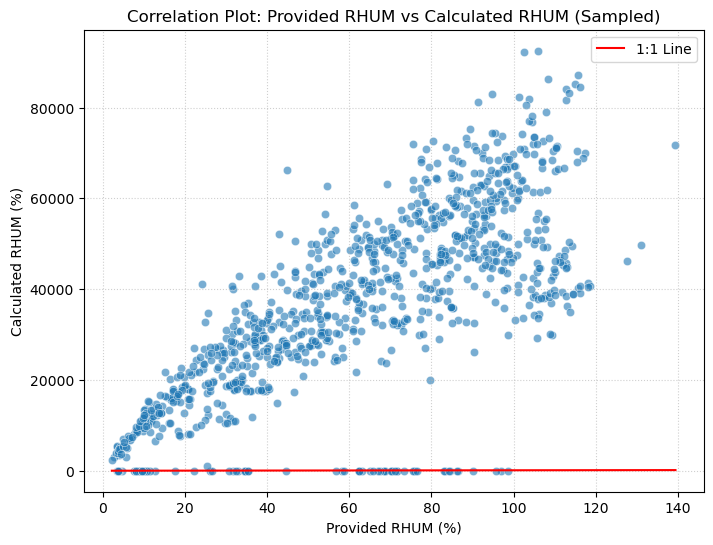

In [16]:
# plot RHUM vs. RH_calc

# Define invalid values
invalid_values = [-999, -9999, -9999.99, -7777.77, -8888.88, -8888, -7777]

# Extract variables
if all(var in combined_ds for var in ['MRTDLL_MC', 'ATX', 'PSXC', 'RHUM']):
    # Extract data
    w = combined_ds['MRTDLL_MC'].values / 1000  # Convert g/kg to kg/kg
    T = combined_ds['ATX'].values  # Temperature in °C
    P = combined_ds['PSXC'].values * 100  # Pressure in Pa (assuming PSXC is in hPa)
    rhum_provided = combined_ds['RHUM'].values  # Provided RH

    # Filter valid values
    valid_mask = (~np.isin(w, invalid_values) & ~np.isnan(w) &
                  ~np.isin(T, invalid_values) & ~np.isnan(T) &
                  ~np.isin(P, invalid_values) & ~np.isnan(P) &
                  ~np.isin(rhum_provided, invalid_values) & ~np.isnan(rhum_provided))
    w_valid = w[valid_mask]
    T_valid = T[valid_mask]
    P_valid = P[valid_mask]
    rhum_valid = rhum_provided[valid_mask]

    # Calculate actual vapor pressure (e) and saturation vapor pressure (es)
    e = (w_valid * P_valid) / (0.622 + 0.378 * w_valid)
    es = 6.112 * np.exp((17.67 * T_valid) / (T_valid + 243.5)) * 100  # Convert hPa to Pa

    # Calculate relative humidity
    rhum_calculated = (e / es) * 100

    # Randomly sample a subset of the data for faster plotting
    sample_size = 1000  # Adjust the sample size as needed
    if len(rhum_valid) > sample_size:
        indices = np.random.choice(len(rhum_valid), size=sample_size, replace=False)
        rhum_valid_sample = rhum_valid[indices]
        rhum_calculated_sample = rhum_calculated[indices]
    else:
        rhum_valid_sample = rhum_valid
        rhum_calculated_sample = rhum_calculated

    # Calculate correlation coefficient
    correlation = np.corrcoef(rhum_valid_sample, rhum_calculated_sample)[0, 1]
    print(f"Correlation between provided RHUM and calculated RHUM: {correlation:.2f}")

    # Plot correlation scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=rhum_valid_sample, y=rhum_calculated_sample, alpha=0.6)
    sns.lineplot(x=rhum_valid_sample, y=rhum_valid_sample, color='red', label='1:1 Line')  # 1:1 line
    plt.title("Correlation Plot: Provided RHUM vs Calculated RHUM (Sampled)")
    plt.xlabel("Provided RHUM (%)")
    plt.ylabel("Calculated RHUM (%)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()
else:
    print("One or more required variables (MRTDLL_MC, ATX, PSXC, RHUM) are not found in the dataset.")

In [17]:
# Debugging: Print statistics of the input variables
print("Statistics for input variables:")
print(f"MRTDLL_MC (g/kg): min={np.nanmin(w * 1000)}, max={np.nanmax(w * 1000)}")
print(f"ATX (°C): min={np.nanmin(T)}, max={np.nanmax(T)}")
print(f"PSXC (hPa): min={np.nanmin(P / 100)}, max={np.nanmax(P / 100)}")

# Debugging: Print statistics of intermediate calculations
print("\nStatistics for intermediate calculations:")
print(f"Actual vapor pressure (e): min={np.nanmin(e)}, max={np.nanmax(e)}")
print(f"Saturation vapor pressure (es): min={np.nanmin(es)}, max={np.nanmax(es)}")
print(f"Calculated RH: min={np.nanmin(rhum_calculated)}, max={np.nanmax(rhum_calculated)}")

Statistics for input variables:
MRTDLL_MC (g/kg): min=6.218905127752805e-06, max=21637.32421875
ATX (°C): min=-39.559696197509766, max=22.666311264038086
PSXC (hPa): min=354.4021911621094, max=882.1226806640625

Statistics for intermediate calculations:
Actual vapor pressure (e): min=0.00035433980519883335, max=186556.578125
Saturation vapor pressure (es): min=19.84304428100586, max=2752.25
Calculated RH: min=3.036172711290419e-05, max=141866.109375


Correlation between provided RHUM and calculated RHUM (T < 0°C): 0.69


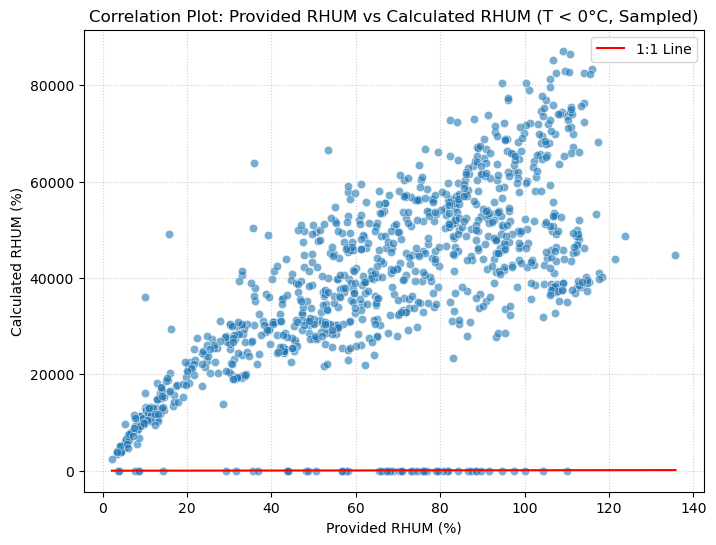

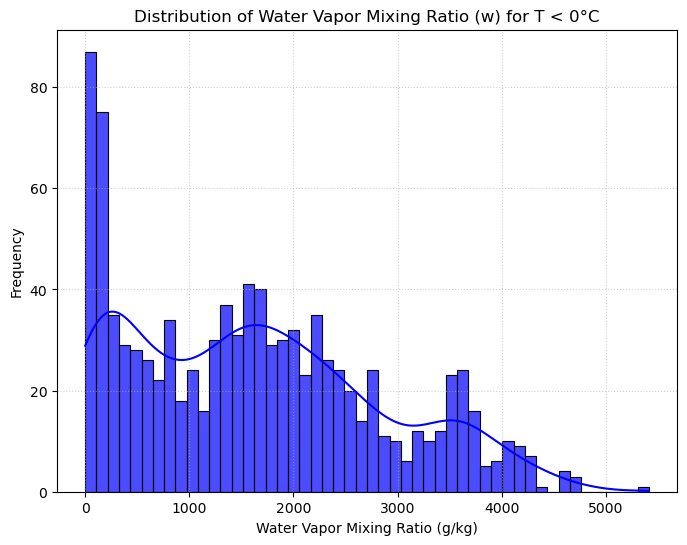

In [19]:
# Repeat analysis, but filter for only cold conditions (T < 0 degC)

# Define invalid values
invalid_values = [-999, -9999, -9999.99, -7777.77, -8888.88, -8888, -7777]

# Extract variables
if all(var in combined_ds for var in ['MRTDLL_MC', 'ATX', 'PSXC', 'RHUM']):
    # Extract data
    w = combined_ds['MRTDLL_MC'].values / 1000  # Convert g/kg to kg/kg
    T = combined_ds['ATX'].values  # Temperature in °C
    P = combined_ds['PSXC'].values * 100  # Pressure in Pa (assuming PSXC is in hPa)
    rhum_provided = combined_ds['RHUM'].values  # Provided RH

    # Filter valid values and temperature < 0°C
    temp_threshold = 0 
    valid_mask = (~np.isin(w, invalid_values) & ~np.isnan(w) &
                  ~np.isin(T, invalid_values) & ~np.isnan(T) & (T < temp_threshold) &
                  ~np.isin(P, invalid_values) & ~np.isnan(P) &
                  ~np.isin(rhum_provided, invalid_values) & ~np.isnan(rhum_provided))
    w_valid = w[valid_mask]
    T_valid = T[valid_mask]
    P_valid = P[valid_mask]
    rhum_valid = rhum_provided[valid_mask]

    # Calculate actual vapor pressure (e) and saturation vapor pressure (es)
    e = (w_valid * P_valid) / (0.622 + 0.378 * w_valid)
    es = 6.112 * np.exp((17.67 * T_valid) / (T_valid + 243.5)) * 100  # Convert hPa to Pa

    # Calculate relative humidity
    rhum_calculated = (e / es) * 100

    # Randomly sample a subset of the data for faster plotting
    sample_size = 1000  # Adjust the sample size as needed
    if len(rhum_valid) > sample_size:
        indices = np.random.choice(len(rhum_valid), size=sample_size, replace=False)
        rhum_valid_sample = rhum_valid[indices]
        rhum_calculated_sample = rhum_calculated[indices]
        w_valid_sample = w_valid[indices]
    else:
        rhum_valid_sample = rhum_valid
        rhum_calculated_sample = rhum_calculated
        w_valid_sample = w_valid

    # Calculate correlation coefficient
    correlation = np.corrcoef(rhum_valid_sample, rhum_calculated_sample)[0, 1]
    print(f"Correlation between provided RHUM and calculated RHUM (T < 0°C): {correlation:.2f}")

    # Plot correlation scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=rhum_valid_sample, y=rhum_calculated_sample, alpha=0.6)
    sns.lineplot(x=rhum_valid_sample, y=rhum_valid_sample, color='red', label='1:1 Line')  # 1:1 line
    plt.title("Correlation Plot: Provided RHUM vs Calculated RHUM (T < 0°C, Sampled)")
    plt.xlabel("Provided RHUM (%)")
    plt.ylabel("Calculated RHUM (%)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()

    # Plot the distribution of w (water vapor mixing ratio)
    plt.figure(figsize=(8, 6))
    sns.histplot(w_valid_sample * 1000, bins=50, kde=True, color="blue", alpha=0.7)
    plt.title("Distribution of Water Vapor Mixing Ratio (w) for T < 0°C")
    plt.xlabel("Water Vapor Mixing Ratio (g/kg)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()
else:
    print("One or more required variables (MRTDLL_MC, ATX, PSXC, RHUM) are not found in the dataset.")

In [20]:
# What portion of TDL measurements is above a reasonable value?
tdl_upper_limit = 50
invalid_values = [-999, -9999, -9999.99, -7777.77, -8888.88, -8888, -7777]

# Extract MRTDLL_MC data
if 'MRTDLL_MC' in combined_ds:
    w = combined_ds['MRTDLL_MC'].values  # Water vapor mixing ratio in g/kg

    # Filter valid values
    valid_mask = (~np.isin(w, invalid_values) & ~np.isnan(w))
    w_valid = w[valid_mask]

    # Check portion of data below 50 g/kg
    below_count = (w_valid < tdl_upper_limit).sum()
    total_count = len(w_valid)
    portion_below = (below_count / total_count) * 100

    print(f"Total valid data points: {total_count}")
    print(f"Data points below {tdl_upper_limit} g/kg: {below_count}")
    print(f"Portion of data below {tdl_upper_limit} g/kg: {portion_below:.2f}%")
else:
    print("Variable MRTDLL_MC not found in the dataset.")

Total valid data points: 199923
Data points below 50 g/kg: 16636
Portion of data below 50 g/kg: 8.32%


In [21]:
# Check proportion of reasonable RHUM

# Define the upper limit for RHUM
rhum_upper_limit = 200
invalid_values = [-999, -9999, -9999.99, -7777.77, -8888.88, -8888, -7777]

# Extract RHUM data
if 'RHUM' in combined_ds:
    rhum = combined_ds['RHUM'].values  # Relative humidity in %

    # Filter valid values
    valid_mask = (~np.isin(rhum, invalid_values) & ~np.isnan(rhum))
    rhum_valid = rhum[valid_mask]

    # Check portion of data below 200%
    below_count = (rhum_valid < rhum_upper_limit).sum()
    total_count = len(rhum_valid)
    portion_below = (below_count / total_count) * 100

    print(f"Total valid data points: {total_count}")
    print(f"Data points below {rhum_upper_limit}%: {below_count}")
    print(f"Portion of data below {rhum_upper_limit}%: {portion_below:.2f}%")
else:
    print("Variable RHUM not found in the dataset.") 

Total valid data points: 209641
Data points below 200%: 209137
Portion of data below 200%: 99.76%


RHUM derived from chilled mirror hygrometer seems to have mostly (>99%) valid values, but the TDL measurements seem to have unreasonable water vapor values that are too high. 

Basic Statistics for MRTDLL_MC (converted to g/kg):
Minimum: 0.0000 g/kg
25th Percentile (Q1): 0.3172 g/kg
Median (Q2): 0.9365 g/kg
75th Percentile (Q3): 1.5382 g/kg
Maximum: 13.4576 g/kg
Mean: 1.0198 g/kg
Standard Deviation: 0.7849 g/kg


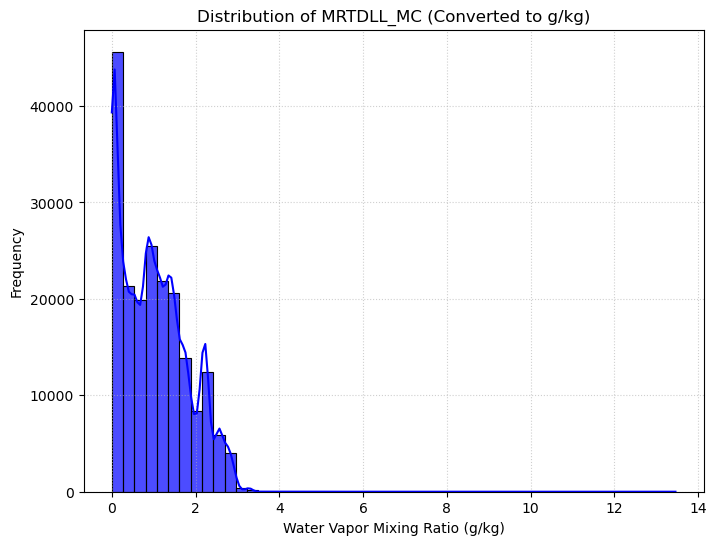

In [22]:
# Is it possible that there is a mistake with units for TDL data?

# assume data is ppmv instead of g/kg

# Constants for conversion
M_w = 18.015  # Molar mass of water (g/mol)
M_a = 28.9647  # Molar mass of dry air (g/mol)

# Extract MRTDLL_MC data
w_ppmv = combined_ds['MRTDLL_MC'].values  # Water vapor mixing ratio in ppmv

# Filter valid values
invalid_values = [-999, -9999, -9999.99, -7777.77, -8888.88, -8888, -7777]
valid_mask = (~np.isin(w_ppmv, invalid_values) & ~np.isnan(w_ppmv))
w_ppmv_valid = w_ppmv[valid_mask]

# Convert ppmv to g/kg
w_g_per_kg = w_ppmv_valid * (M_w / M_a) / 1000

# Calculate basic statistics
quartiles = np.percentile(w_g_per_kg, [25, 50, 75])
min_value = np.min(w_g_per_kg)
max_value = np.max(w_g_per_kg)
mean_value = np.mean(w_g_per_kg)
std_dev = np.std(w_g_per_kg)

# Print statistics
print("Basic Statistics for MRTDLL_MC (converted to g/kg):")
print(f"Minimum: {min_value:.4f} g/kg")
print(f"25th Percentile (Q1): {quartiles[0]:.4f} g/kg")
print(f"Median (Q2): {quartiles[1]:.4f} g/kg")
print(f"75th Percentile (Q3): {quartiles[2]:.4f} g/kg")
print(f"Maximum: {max_value:.4f} g/kg")
print(f"Mean: {mean_value:.4f} g/kg")
print(f"Standard Deviation: {std_dev:.4f} g/kg")

# Plot the distribution
plt.figure(figsize=(8, 6))
sns.histplot(w_g_per_kg, bins=50, kde=True, color="blue", alpha=0.7)
plt.title("Distribution of MRTDLL_MC (Converted to g/kg)")
plt.xlabel("Water Vapor Mixing Ratio (g/kg)")
plt.ylabel("Frequency")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

This seems like a more reasonable distribution! Units are likely incorrect in the data files. 

Correlation between provided RHUM and calculated RHUM (T < 0°C): 0.8045
Calculated RH - Min: 0.00%, Max: 100.76%
Provided RHUM - Min: 2.20%, Max: 139.65%


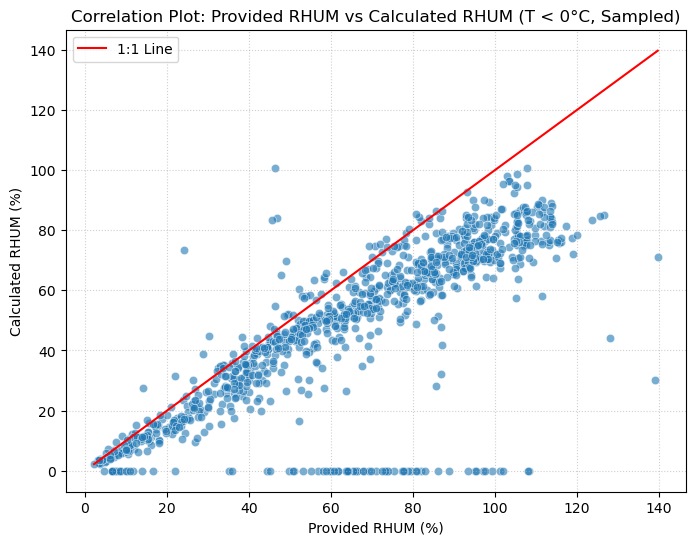

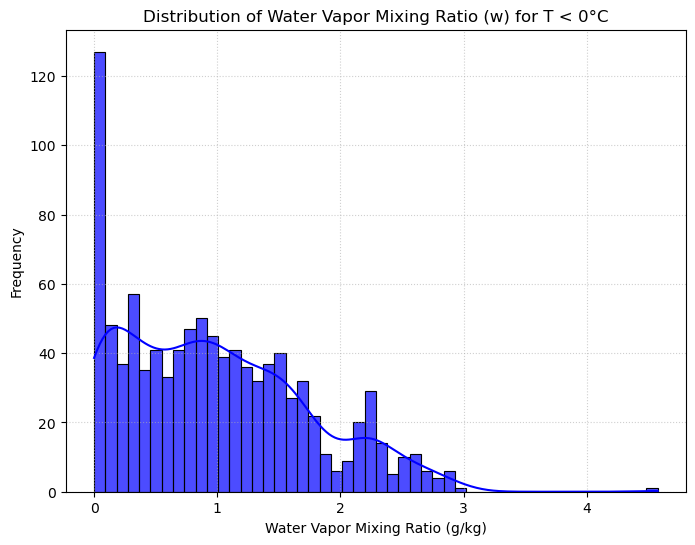

In [26]:
# Re-do analysis, with correct water vapor units (ppmv)

# Constants for conversion
M_w = 18.015  # Molar mass of water (g/mol)
M_a = 28.9647  # Molar mass of dry air (g/mol)

# Define invalid values
invalid_values = [-999, -9999, -9999.99, -7777.77, -8888.88, -8888, -7777]

# Extract variables
if all(var in combined_ds for var in ['MRTDLL_MC', 'ATX', 'PSXC', 'RHUM']):
    # Extract data
    w_ppmv = combined_ds['MRTDLL_MC'].values  # Water vapor mixing ratio in ppmv
    T = combined_ds['ATX'].values  # Temperature in °C
    P_hpa = combined_ds['PSXC'].values  # Pressure in hPa
    rhum_provided = combined_ds['RHUM'].values  # Provided RH

    # Convert ppmv to g/kg
    w = w_ppmv * (M_w / M_a) / 1000  # Convert ppmv to g/kg

    # Filter valid values and temperature < 0°C
    temp_threshold = 0
    valid_mask = (~np.isin(w, invalid_values) & ~np.isnan(w) &
                  ~np.isin(T, invalid_values) & ~np.isnan(T) & (T < temp_threshold) &
                  ~np.isin(P_hpa, invalid_values) & ~np.isnan(P_hpa) &
                  ~np.isin(rhum_provided, invalid_values) & ~np.isnan(rhum_provided))
    w_valid = w[valid_mask]
    T_valid = T[valid_mask]
    P_valid = P_hpa[valid_mask]  # Keep in hPa
    rhum_valid = rhum_provided[valid_mask]

    # Calculate actual vapor pressure (e) in hPa
    w_kg_per_kg = w_valid / 1000  # Convert g/kg to kg/kg
    e = (w_kg_per_kg * P_valid) / (0.622 + w_kg_per_kg)

    # Calculate saturation vapor pressure (es) in hPa using Magnus-Tetens formula
    es = 6.112 * np.exp((17.67 * T_valid) / (T_valid + 243.5))

    # Calculate relative humidity
    rhum_calculated = (e / es) * 100

    # Randomly sample a subset of the data for faster plotting
    sample_size = 1000
    if len(rhum_valid) > sample_size:
        indices = np.random.choice(len(rhum_valid), size=sample_size, replace=False)
        rhum_valid_sample = rhum_valid[indices]
        rhum_calculated_sample = rhum_calculated[indices]
        w_valid_sample = w_valid[indices]
    else:
        rhum_valid_sample = rhum_valid
        rhum_calculated_sample = rhum_calculated
        w_valid_sample = w_valid

    # Calculate correlation coefficient
    correlation = np.corrcoef(rhum_valid_sample, rhum_calculated_sample)[0, 1]
    print(f"Correlation between provided RHUM and calculated RHUM (T < 0°C): {correlation:.4f}")
    print(f"Calculated RH - Min: {rhum_calculated_sample.min():.2f}%, Max: {rhum_calculated_sample.max():.2f}%")
    print(f"Provided RHUM - Min: {rhum_valid_sample.min():.2f}%, Max: {rhum_valid_sample.max():.2f}%")

    # Plot correlation scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=rhum_valid_sample, y=rhum_calculated_sample, alpha=0.6)
    sns.lineplot(x=rhum_valid_sample, y=rhum_valid_sample, color='red', label='1:1 Line')
    plt.title("Correlation Plot: Provided RHUM vs Calculated RHUM (T < 0°C, Sampled)")
    plt.xlabel("Provided RHUM (%)")
    plt.ylabel("Calculated RHUM (%)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()

    # Plot the distribution of w
    plt.figure(figsize=(8, 6))
    sns.histplot(w_valid_sample, bins=50, kde=True, color="blue", alpha=0.7)
    plt.title("Distribution of Water Vapor Mixing Ratio (w) for T < 0°C")
    plt.xlabel("Water Vapor Mixing Ratio (g/kg)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()
else:
    print("One or more required variables (MRTDLL_MC, ATX, PSXC, RHUM) are not found in the dataset.")

The correlation betweeen calculate RH and RHUM in the dataset is much better now. The issue was most likely an issue with the units of water vapor measurements. The units are PPMV not g/kg.

# IPHEX
- data in *.iphex text files
- no DLH measurements
- use chilled mirror hygrometer to derive Si

In [3]:
# load and combine data
def find_data_start(filepath):
    """
    Find the line number where actual data starts.
    Looks for the line with column names (containing 'Time' and units).
    """
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            # Look for the line with column names (starts with "Time")
            if line.strip().startswith('Time') and 'Air_Temp' in line:
                # Data starts 2 lines after: next line is units, then data
                return i + 2
    return None

def read_iphex_file(filepath):
    """
    Read a single IPHEX file and return a pandas DataFrame.
    """
    # Find where data starts
    data_start = find_data_start(filepath)
    
    if data_start is None:
        print(f"Warning: Could not find data start in {filepath}")
        return None
    
    # Read column names from the line before units
    with open(filepath, 'r') as f:
        lines = f.readlines()
        column_line = lines[data_start - 2].strip()
        
    # Parse column names (they're space-separated)
    column_names = column_line.split()
    
    # Read the data
    try:
        df = pd.read_csv(
            filepath,
            skiprows=data_start,
            sep=r'\s+',  # Use regex to handle whitespace as a separator
            names=column_names,
            na_values=['999999.9999', '999.9999999', '9999.999999', 
                      '99999.99999', '99999999999', '9.999E+30'],
            low_memory=False
        )
        
        # Add source file column
        df['source_file'] = Path(filepath).name
        
        # Extract date from filename (format: YYYY_MM_DD_HH_MM_SS.iphex)
        filename = Path(filepath).stem
        date_parts = filename.split('_')[:6]
        if len(date_parts) == 6:
            try:
                date_str = f"{date_parts[0]}-{date_parts[1]}-{date_parts[2]} {date_parts[3]}:{date_parts[4]}:{date_parts[5]}"
                df['file_date'] = pd.to_datetime(date_str)
            except:
                df['file_date'] = None
        
        return df
        
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

def load_all_iphex_files(directory):
    """
    Load all IPHEX files from a directory (excluding 'Combined' files).
    Returns a single combined DataFrame.
    """
    # Get all .iphex files
    data_dir = Path(directory)
    iphex_files = list(data_dir.glob('*.iphex'))
    
    # Filter out files with 'Combined' in the name
    iphex_files = [f for f in iphex_files if 'Combined' not in f.name]
    
    print(f"Found {len(iphex_files)} IPHEX files to process")
    
    # Read all files
    dfs = []
    for i, filepath in enumerate(iphex_files, 1):
        print(f"Processing file {i}/{len(iphex_files)}: {filepath.name}")
        df = read_iphex_file(filepath)
        if df is not None and not df.empty:
            dfs.append(df)
    
    # Combine all dataframes
    if dfs:
        combined_df = pd.concat(dfs, ignore_index=True)
        print(f"\nSuccessfully combined {len(dfs)} files")
        print(f"Total rows: {len(combined_df)}")
        print(f"Total columns: {len(combined_df.columns)}")
        return combined_df
    else:
        print("No data files were successfully read")
        return None

# Usage:
# Replace with your actual directory path
directory_path = '/home/jko/ssl-cpi-analysis/data/env/IPHEX'

# Load all data
df = load_all_iphex_files(directory_path)

# Display basic information
if df is not None:
    print("\n" + "="*50)
    print("Data Summary:")
    print("="*50)
    print(f"\nShape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nFirst few rows:")
    print(df.head())
    print(f"\nData types:")
    print(df.dtypes)
    print(f"\nMissing values per column:")
    print(df.isnull().sum())

Found 32 IPHEX files to process
Processing file 1/32: 2014_05_16_10_14_27.iphex
Processing file 2/32: 2014_06_05_07_11_34.iphex
Processing file 3/32: 2014_05_18_10_55_51.iphex
Processing file 4/32: 2014_06_08_18_07_30.iphex
Processing file 5/32: 2014_04_16_16_33_26.iphex
Processing file 6/32: 2014_03_06_17_45_37.iphex
Processing file 7/32: 2014_05_12_17_45_18.iphex
Processing file 8/32: 2014_05_23_22_04_48.iphex
Processing file 9/32: 2014_05_19_06_07_13.iphex
Processing file 10/32: 2014_05_26_19_58_48.iphex
Processing file 11/32: 2014_04_22_20_46_40.iphex
Processing file 12/32: 2014_06_06_18_21_47.iphex
Processing file 13/32: 2014_05_19_09_01_04.iphex
Processing file 14/32: 2014_05_16_17_00_32.iphex
Processing file 15/32: 2014_05_25_18_59_17.iphex
Processing file 16/32: 2014_06_13_18_51_49.iphex
Processing file 17/32: 2014_05_10_15_38_13.iphex
Processing file 18/32: 2014_05_16_12_37_36.iphex
Processing file 19/32: 2014_05_27_21_13_09.iphex
Processing file 20/32: 2014_05_29_17_25_29.iph

In [4]:
df.head()

,Time,Air_Temp,MachNo_N,IAS,TAS,Press_Alt,Pot_Temp_T1,Pitot_Wing,CABIN_PRES,STATIC_PR,...,Nt2DSV_all,Nt_HVPS3V,source_file,file_date,2-DC_Conc,2-DC_MenD,2-DC_VolDia,2-DC_EffRad,d,HVPS3Media
0,36868.8,7.2425,0.0566,18.5249,18.9856,635.3923,285.4713,2.1051,943.7754,939.1367,...,NaN,NaN,2014_05_16_10_14_27.iphex,2014-05-16 10:14:27,NaN,NaN,NaN,NaN,NaN,NaN
1,36869.8,7.2408,0.0568,18.6227,19.0859,635.5040,285.4706,2.1273,943.7956,939.1240,...,NaN,NaN,2014_05_16_10_14_27.iphex,2014-05-16 10:14:27,NaN,NaN,NaN,NaN,NaN,NaN
2,36870.8,7.2385,0.0575,18.8397,19.3080,635.3365,285.4666,2.1773,943.7720,939.1430,...,NaN,NaN,2014_05_16_10_14_27.iphex,2014-05-16 10:14:27,NaN,NaN,NaN,NaN,NaN,NaN
3,36871.8,7.2336,0.0571,18.7112,19.1763,635.4481,285.4627,2.1478,943.8174,939.1303,...,0.0,0.0,2014_05_16_10_14_27.iphex,2014-05-16 10:14:27,NaN,NaN,NaN,NaN,NaN,NaN
4,36872.8,7.2343,0.0570,18.6668,19.1307,635.3253,285.4622,2.1376,943.7956,939.1442,...,0.0,0.0,2014_05_16_10_14_27.iphex,2014-05-16 10:14:27,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.columns

Index(['Time', 'Air_Temp', 'MachNo_N', 'IAS', 'TAS', 'Press_Alt',
       'Pot_Temp_T1', 'Pitot_Wing', 'CABIN_PRES', 'STATIC_PR', 'DEWPT',
       'MixingRatio', 'DewPoint', 'FrostPoint', 'POS_Roll', 'POS_Pitch',
       'POS_Head', 'POSZ_Acc', 'POS_Lat', 'POS_Lon', 'POS_Alt', 'POS_Spd',
       'POS_Trk', 'Alpha', 'Beta', 'VERT_VEL', 'Wind_Z', 'Wind_M', 'Wind_D',
       'TURB', 'King_LWC_ad', 'Nev_TWC', 'Nev_LWC', 'CDP_Conc', 'CDP_LWC',
       'CDP_MenD', 'CDP_VolDia', 'CDP_EffRad', '2-DC_Conch', '2-DC_MenDh',
       '2-DCVolDiah', '2-DCEffRadh', 'IceMSOFreq', 'CPCConc', 'TSG_Date',
       'CSI_M_Ratio', 'CSI_CWC', 'Nt2DSHGT105', 'Nt2DSH_all', 'Nt2DSVGT105',
       'Nt2DSV_all', 'Nt_HVPS3V', 'source_file', 'file_date', '2-DC_Conc',
       '2-DC_MenD', '2-DC_VolDia', '2-DC_EffRad', 'd', 'HVPS3Media'],
      dtype='object')

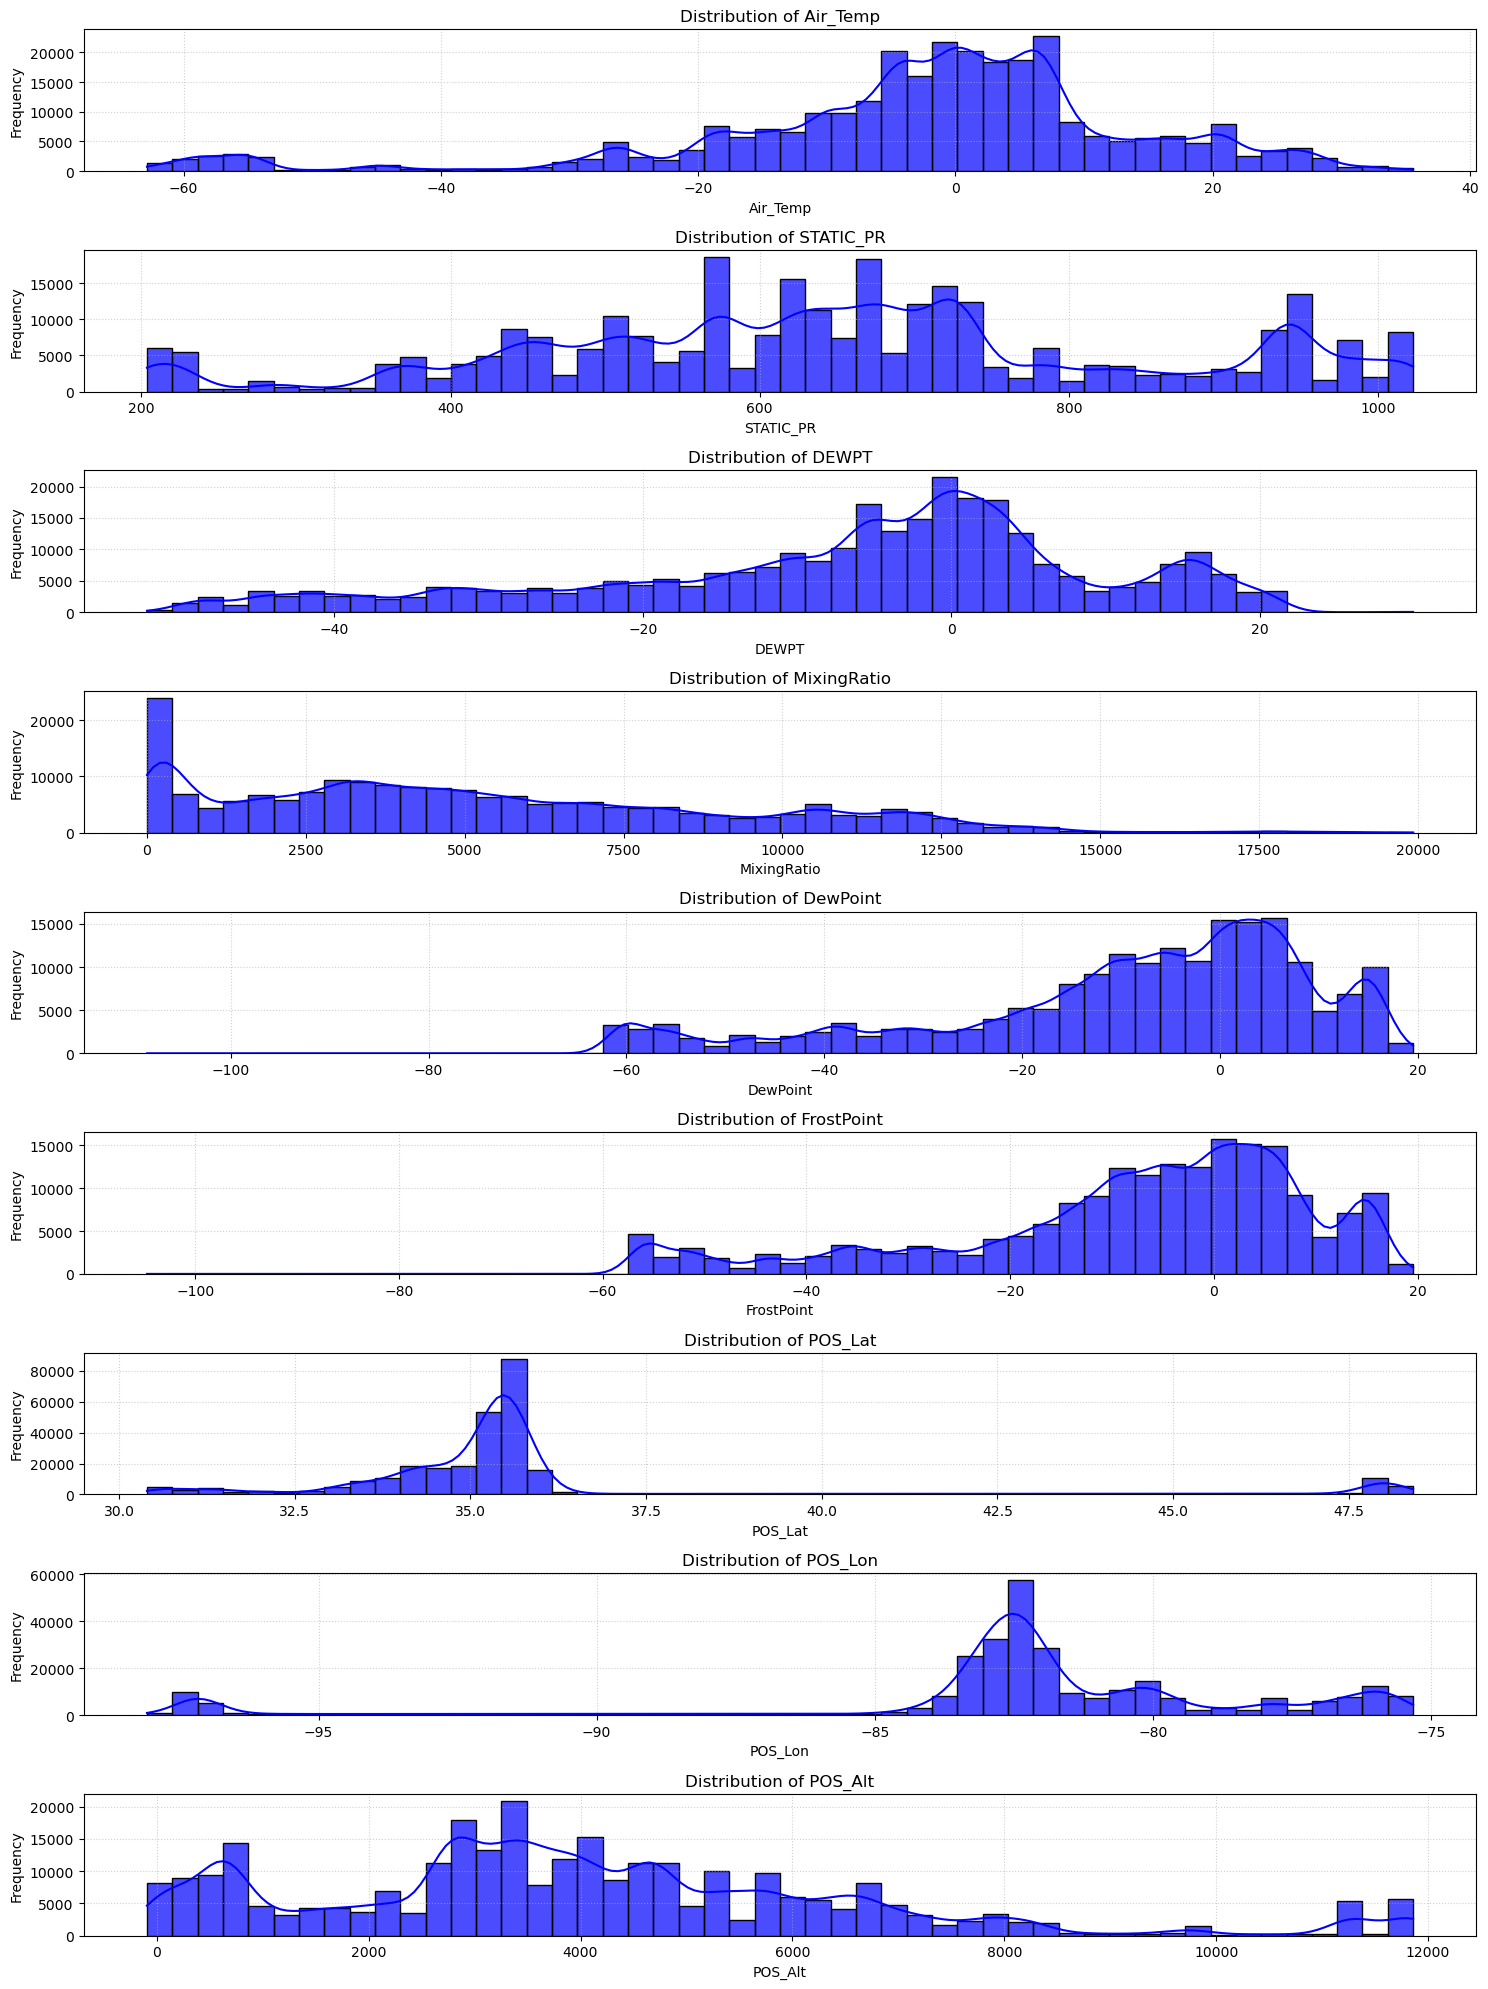

In [12]:
# Plot distributions of env variables

# List of environmental variables to plot
env_vars = ['Air_Temp', 'STATIC_PR', 'DEWPT', 'MixingRatio', 'DewPoint', 
            'FrostPoint', 'POS_Lat', 'POS_Lon', 'POS_Alt']

# Plot distributions
plt.figure(figsize=(15, 20))
for i, var in enumerate(env_vars, 1):
    if var in df.columns:
        plt.subplot(len(env_vars), 1, i)
        sns.histplot(df[var].dropna(), bins=50, kde=True, color="blue", alpha=0.7)
        plt.title(f"Distribution of {var}")
        plt.xlabel(var)
        plt.ylabel("Frequency")
        plt.grid(True, linestyle=":", alpha=0.6)
    else:
        print(f"Warning: {var} not found in the DataFrame")

plt.tight_layout()
plt.show()


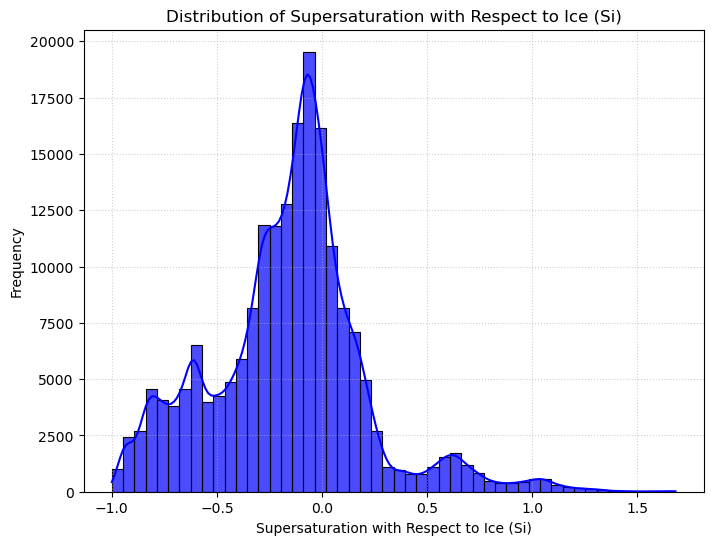

Basic Statistics for Supersaturation with Respect to Ice (Si):
Minimum: -1.0000
25th Percentile (Q1): -0.3599
Median (Q2): -0.1299
75th Percentile (Q3): 0.0168
Maximum: 1.6811
Mean: -0.1615
Standard Deviation: 0.3688


In [13]:
# Calculate Si and examine distribution

# Ensure required columns exist in the DataFrame
required_columns = ['FrostPoint', 'Air_Temp', 'STATIC_PR']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Missing columns in DataFrame: {missing_columns}")
else:
    # Filter valid data
    invalid_values = [999999.9999, 999.9999999, 9999.999999, 99999.99999, 99999999999, 9.999E+30]
    valid_mask = (~df['FrostPoint'].isin(invalid_values) & ~df['Air_Temp'].isin(invalid_values) &
                  ~df['STATIC_PR'].isin(invalid_values) & ~df['FrostPoint'].isna() &
                  ~df['Air_Temp'].isna() & ~df['STATIC_PR'].isna())
    frost_point = df.loc[valid_mask, 'FrostPoint']
    air_temp = df.loc[valid_mask, 'Air_Temp']
    static_pr = df.loc[valid_mask, 'STATIC_PR']

    # Calculate actual vapor pressure (e) from FrostPoint
    e = 6.112 * np.exp((22.46 * frost_point) / (272.62 + frost_point))  # e in hPa

    # Calculate saturation vapor pressure over ice (e_i) from Air_Temp
    e_i = 6.112 * np.exp((22.46 * air_temp) / (272.62 + air_temp))  # e_i in hPa

    # Calculate supersaturation with respect to ice (Si)
    si = (e / e_i) - 1

    # Plot the distribution of Si
    plt.figure(figsize=(8, 6))
    sns.histplot(si, bins=50, kde=True, color="blue", alpha=0.7)
    plt.title("Distribution of Supersaturation with Respect to Ice (Si)")
    plt.xlabel("Supersaturation with Respect to Ice (Si)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()

    # Print basic statistics for Si
    print("Basic Statistics for Supersaturation with Respect to Ice (Si):")
    print(f"Minimum: {np.min(si):.4f}")
    print(f"25th Percentile (Q1): {np.percentile(si, 25):.4f}")
    print(f"Median (Q2): {np.percentile(si, 50):.4f}")
    print(f"75th Percentile (Q3): {np.percentile(si, 75):.4f}")
    print(f"Maximum: {np.max(si):.4f}")
    print(f"Mean: {np.mean(si):.4f}")
    print(f"Standard Deviation: {np.std(si):.4f}")

Some extreme values present in the distribution. Should probably filter out.

# ISDAC

In [2]:
# Read and combine data files
def find_header_row(filepath):
    """
    Find the row number where column names are located.
    The column names row is identified by having 'HH,MM,SS' at the start.
    """
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if line.strip().startswith('HH,MM,SS'):
                return i
    return None

def make_unique_columns(col_names):
    """
    Make column names unique by appending _1, _2, etc. to duplicates.
    """
    seen = {}
    unique_names = []
    
    for name in col_names:
        # Handle empty strings
        if name == '' or name.isspace():
            name = 'unnamed'
        
        # If we've seen this name before, add a suffix
        if name in seen:
            seen[name] += 1
            unique_names.append(f"{name}_{seen[name]}")
        else:
            seen[name] = 0
            unique_names.append(name)
    
    return unique_names

def read_strapp_file(filepath):
    """
    Read a single STRAPP data file.
    
    Returns:
        pandas.DataFrame with the data
    """
    # Find where the column names are
    header_row = find_header_row(filepath)
    
    if header_row is None:
        raise ValueError(f"Could not find header row in {filepath}")
    
    # Read the column names
    with open(filepath, 'r') as f:
        lines = f.readlines()
        col_names = lines[header_row].strip().split(',')
        col_names = [name.strip() for name in col_names]
    
    # Make column names unique
    col_names = make_unique_columns(col_names)
    
    # Use regex to match any negative number consisting only of 8s or 9s
    na_pattern = r"^-8+$|^-9+$|^-8+\.\d+$|^-9+\.\d+$"
    
    # Read the data, skipping header rows
    df = pd.read_csv(
        filepath,
        skiprows=header_row + 3,  # Skip header, units, separator
        names=col_names,
        na_values=na_pattern,
        skipinitialspace=True
    )
    
    return df

def combine_strapp_files(data_dir):
    """
    Combine all STRAPP data files in a directory.
    
    Args:
        data_dir: Path to directory containing the .txt files
        
    Returns:
        pandas.DataFrame with all data combined
    """
    data_dir = Path(data_dir)
    
    # Find all .txt files
    file_pattern = str(data_dir / "*.txt")
    files = sorted(glob.glob(file_pattern))
    
    print(f"Found {len(files)} files")
    
    if len(files) == 0:
        raise ValueError(f"No .txt files found in {data_dir}")
    
    # Read all files
    dfs = []
    for filepath in files:
        try:
            print(f"Reading {Path(filepath).name}...")
            df = read_strapp_file(filepath)
            
            # Add a column to identify which file the data came from
            df['source_file'] = Path(filepath).stem
            
            dfs.append(df)
            print(f"  -> {len(df)} rows, {len(df.columns)} columns")
            
        except Exception as e:
            print(f"Error reading {filepath}: {e}")
            continue
    
    # Combine all dataframes
    if len(dfs) == 0:
        raise ValueError("No files were successfully read")
    
    combined_df = pd.concat(dfs, ignore_index=True)
    
    print(f"\n{'='*60}")
    print(f"Total rows: {len(combined_df)}")
    print(f"Total columns: {len(combined_df.columns)}")
    print(f"{'='*60}")
    
    return combined_df


data_dir = "/home/jko/ssl-cpi-analysis/data/env/ISDAC/strapp-convair_bulk/CommaDelimited"

# Combine all files
df = combine_strapp_files(data_dir)

# Display info
print("\nFirst few rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataFrame info:")
print(df.info())

Found 28 files
Reading 001F08_195924.txt...
  -> 8984 rows, 67 columns
Reading 001F09_195941.txt...
  -> 13565 rows, 67 columns
Reading 001F10_003300.txt...
  -> 10767 rows, 67 columns
Reading 001F11_173610.txt...
  -> 13630 rows, 67 columns
Reading 001F12_224551.txt...
  -> 16087 rows, 67 columns
Reading 001F13_173728.txt...
  -> 14242 rows, 67 columns
Reading 001F14_223423.txt...
  -> 14574 rows, 67 columns
Reading 001F15_150020.txt...
  -> 13672 rows, 67 columns
Reading 001F16_195400.txt...
  -> 13343 rows, 67 columns
Reading 001F17_001232.txt...
  -> 6302 rows, 67 columns
Reading 001F18_152117.txt...
  -> 12967 rows, 67 columns
Reading 001F19_200744.txt...
  -> 15368 rows, 67 columns
Reading 001F20_180307.txt...
  -> 14874 rows, 67 columns
Reading 001F21_232534.txt...
  -> 12755 rows, 67 columns
Reading 001F22_150823.txt...
  -> 14799 rows, 67 columns
Reading 001F23_201540.txt...
  -> 15001 rows, 67 columns
Reading 001F24_012122.txt...
  -> 6438 rows, 67 columns
Reading 001F25_1936

In [4]:
df.columns

Index(['HH', 'MM', 'SS', 'HH_1', 'MM_1', 'SS_1', 'ThkAlt', 'PreAlt', 'ALT_G',
       'NPres', 'BCPres', 'KT-19', 'RSTem', 'RFTS', 'EGGDew', 'ReHuW', 'ReHuI',
       'LicDew', 'LicFro', 'BmTAS', 'BmLAS', 'HDG', 'TRK', 'ALPHA', 'BETA',
       'PITCH', 'ROLL', 'driftA', 'MastrLAT', 'MasterLON', 'PosStat', 'Brg01',
       'Range01', 'MWSpd', 'MWDir', 'VWND_P', 'NevCExt', 'R96', 'F96CncX',
       'F96Ext', 'FS96MeVD', 'F6LWC', 'R02', 'F02XCnc', 'F02Ext', 'FS02MeVD',
       'F02LWC', 'CDPTot', 'CDPMedVD', 'CDPExt', 'CDPLWC', 'F300Cnc',
       'F3C>2um', 'KSzrLW', 'CSI_TCWC', 'CSITCWzr', 'ROSIC1', 'RIDInd',
       '2DC0ShdOr', '2DP1ShdOr', 'PCTcon', 'CVIFlg', 'CVISamP', 'CVISamT',
       'CVISampFl', 'CVI_Eh', 'source_file'],
      dtype='object')

Explanation of duplicate time columns:  

The ISDAC data includes two sets of "HH,MM,SS" columns: **UTC Time** (true Coordinated Universal Time for global alignment) and **DAS Time** (Data Acquisition System time for onboard synchronization). Duplicate column names arise because both use the same format. To avoid confusion, rename columns (e.g., `UTC_HH`, `UTC_MM`, `DAS_HH`, `DAS_MM`). Use **UTC Time** for external alignment and **DAS Time** for internal synchronization with aircraft systems.

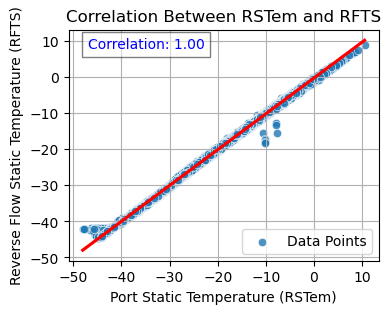

In [11]:
# Plot correlation with two different temp measurements

# Drop rows with NaN values in the relevant columns
n_samples = 10_000
temp_df = df[['RSTem', 'RFTS']].dropna()

# Subsample the data
temp_df = temp_df.sample(n=n_samples, random_state=42)

# Calculate the correlation coefficient
corr_coef, _ = pearsonr(temp_df['RSTem'], temp_df['RFTS'])

# Create the scatter plot
plt.figure(figsize=(4, 3))
sns.scatterplot(data=temp_df, x='RSTem', y='RFTS', alpha=0.8, label='Data Points')

# Add a line of best fit
sns.regplot(data=temp_df, x='RSTem', y='RFTS', scatter=False, color='red', line_kws={'label': 'Best Fit Line'})

# Add labels and title
plt.xlabel('Port Static Temperature (RSTem)')
plt.ylabel('Reverse Flow Static Temperature (RFTS)')
plt.title('Correlation Between RSTem and RFTS')

# Annotate the correlation coefficient
plt.text(
    x=temp_df['RSTem'].min() + 1,  # Adjust x position
    y=temp_df['RFTS'].max() - 1,  # Adjust y position
    s=f"Correlation: {corr_coef:.2f}",
    color='blue',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.5)
)

plt.legend()
plt.grid(True)

# Show the plot
plt.show()

There appears to be a good correlation between the two. Just so with the standard port static temp measurement for consistency with past campaigns.

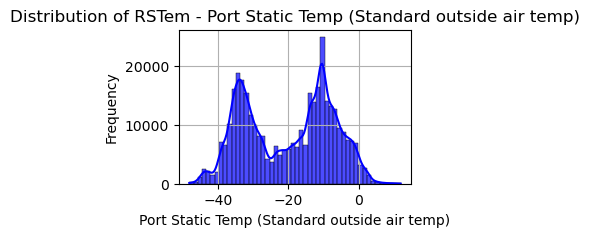

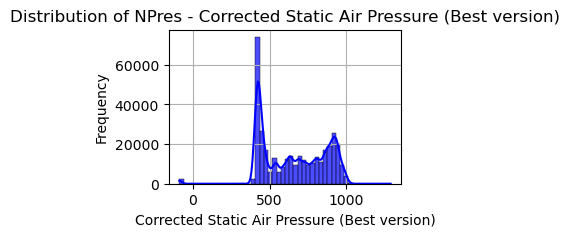

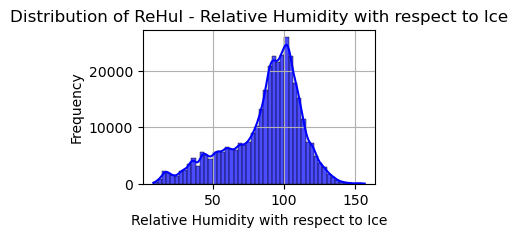

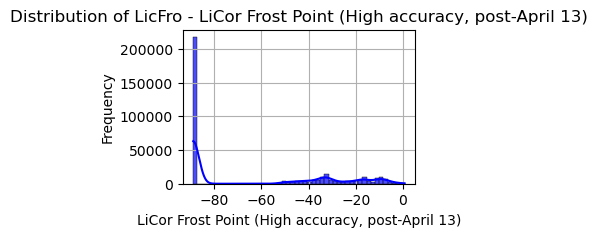

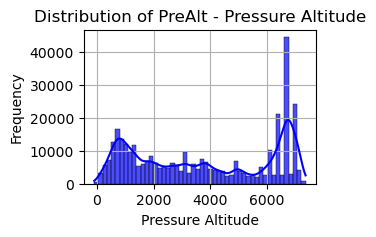

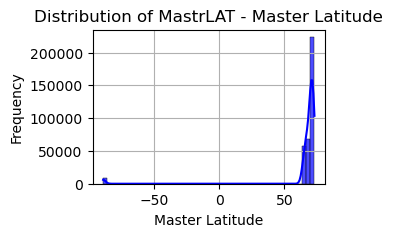

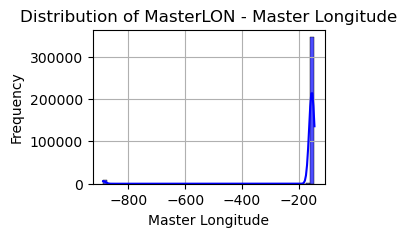

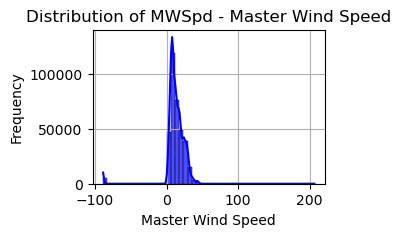

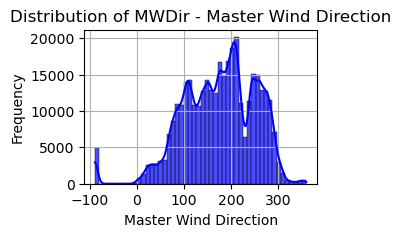

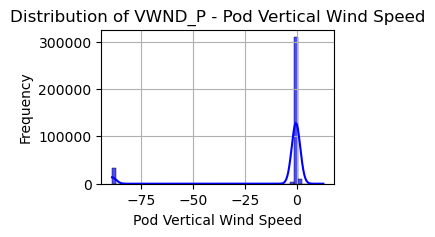

In [14]:
# List of environmental variables and their descriptions
isdac_env_vars = {
    'RSTem': 'Port Static Temp (Standard outside air temp)',
    'NPres': 'Corrected Static Air Pressure (Best version)',
    'ReHuI': 'Relative Humidity with respect to Ice',
    'LicFro': 'LiCor Frost Point (High accuracy, post-April 13)',
    'PreAlt': 'Pressure Altitude',
    'MastrLAT': 'Master Latitude',
    'MasterLON': 'Master Longitude',
    'MWSpd': 'Master Wind Speed',
    'MWDir': 'Master Wind Direction',
    'VWND_P': 'Pod Vertical Wind Speed'
}

# Plot the distribution of each variable
for var, description in isdac_env_vars.items():
    if var in df.columns:  # Check if the variable exists in the DataFrame
        plt.figure(figsize=(3, 2))
        sns.histplot(df[var].dropna(), kde=True, bins=50, color='blue', alpha=0.7)
        plt.title(f'Distribution of {var} - {description}')
        plt.xlabel(description)
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.show()
    else:
        print(f"Variable '{var}' not found in the DataFrame.")

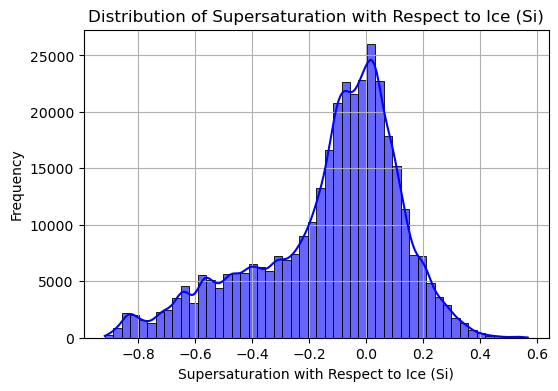

In [16]:
# Convert RHi to Si and plot distribution
# Drop rows with NaN values in the relevant columns
temp_df = df[['ReHuI']].dropna()

# Convert ReHuI to Si
temp_df['Si'] = (temp_df['ReHuI'] / 100) - 1

# Plot the distribution of Si
plt.figure(figsize=(6, 4))
sns.histplot(temp_df['Si'], kde=True, bins=50, color='blue', alpha=0.6)
plt.title('Distribution of Supersaturation with Respect to Ice (Si)')
plt.xlabel('Supersaturation with Respect to Ice (Si)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# MACPEX

- This field campaign had many vapor measurements for intercomparison
- Each instrument data in their own respective subfolders

In [75]:
# Find the time column for each instrument
root = Path("/home/jko/ssl-cpi-analysis/data/env/MACPEX")

def get_colnames(path: Path):
    """
    Extract column names from an ICT file.
    """
    lines = path.read_text().splitlines()
    n_header = int(lines[0].replace(" ", "").split(",")[0])
    col_line = lines[n_header - 1]
    return [c.strip() for c in col_line.split(",") if c.strip()]

def is_time(col: str):
    """
    Check if a column name is a time column (contains 'time' or 'utc').
    """
    return bool(re.search(r"time|utc", col, flags=re.IGNORECASE))

time_cols = {}

for f in sorted(root.rglob("*.ict")):
    cols = get_colnames(f)
    tcols = [c for c in cols if is_time(c)]
    inst = f.parent.name  # instrument folder

    # Save the time column as a single string if there is exactly one time column
    if len(tcols) == 1:
        time_cols[inst] = tcols[0]
    elif len(tcols) > 1:
        print(f"Warning: Multiple time columns found for {inst}: {tcols}")
    else:
        print(f"Warning: No time column found for {inst}")

# Print per instrument
for inst, col in time_cols.items():
    print(f"{inst}: {col}")

CIMS: UTC_s
CLH: Time_UTC
DLH: Time_UTC
HWV: Time_UTC
JLH: Start_UTC
MMS-Met: TIME_UTC
ULH: Start_UTC


In [76]:
# Helper functions to read and parse MACPEX ICT files
def parse_ict_file(filepath):
    """
    Robustly parse NASA ICARTT format (.ict) files
    """
    filepath = Path(filepath)
    
    with open(filepath, 'r') as f:
        first_line = f.readline().strip()
        n_header_lines = int(first_line.split(',')[0])
        
        f.seek(0)
        header_lines = [f.readline().strip() for _ in range(n_header_lines)]
    
    # --- Find the date line ---
    # ICARTT date line format: "YYYY, MM, DD, YYYY, MM, DD"
    # (flight date, data revision date)
    # Search for a line with exactly 6 comma-separated integers that look like dates
    flight_date = None
    for line in header_lines:
        parts = [p.strip() for p in line.split(',')]
        # Date line has 4-6 parts, first 3 should be year (>1900), month (1-12), day (1-31)
        if len(parts) >= 3:
            try:
                year, month, day = int(parts[0]), int(parts[1]), int(parts[2])
                if 1990 < year < 2100 and 1 <= month <= 12 and 1 <= day <= 31:
                    flight_date = pd.Timestamp(year=year, month=month, day=day)
                    break
            except ValueError:
                continue
    
    if flight_date is None:
        raise ValueError(f"Could not find flight date in header of {filepath.name}")
    
    # --- Extract column names (last header line) ---
    col_line = header_lines[-1]
    columns = [col.strip() for col in col_line.split(',') if col.strip()]
    
    # --- Get time column for this instrument ---
    instrument = filepath.parent.name
    time_col = time_cols.get(instrument)
    
    if time_col is None:
        raise ValueError(f"Unknown instrument: {instrument}")
    
    if time_col not in columns:
        raise ValueError(f"Time column '{time_col}' not found in {filepath.name}. Available: {columns}")
    
    # --- Read data ---
    df = pd.read_csv(
        filepath,
        skiprows=n_header_lines,
        names=columns,
        na_values=['', ' ', 'NA', 'NaN'],
        skipinitialspace=True,
        on_bad_lines='skip'
    )
    
    df.columns = df.columns.str.strip()
    
    # --- Create datetime_utc ---
    df['datetime_utc'] = flight_date + pd.to_timedelta(df[time_col], unit='s')
    
    # --- Handle missing data flags ---
    missing_flags = [-9999, -9999.99, -7777, -7777.77, -8888, -8888.88]
    for col in df.select_dtypes(include=[np.number]).columns:
        if col != time_col:
            df[col] = df[col].replace(missing_flags, np.nan)
    
    # --- Rename columns with instrument prefix ---
    file_prefix = filepath.stem.split('_')[0]
    data_cols = [col for col in df.columns if col not in [time_col, 'datetime_utc']]
    rename_dict = {col: f"{file_prefix}_{col}" for col in data_cols}
    df = df.rename(columns=rename_dict)
    
    keep_cols = ['datetime_utc'] + [f"{file_prefix}_{col}" for col in data_cols]
    df = df[keep_cols]
    
    return df


def combine_ict_files(file_list, time_tolerance='1S'):
    """
    Combine multiple ICT files on unified datetime_utc
    """
    dfs = []
    
    for filepath in file_list:
        try:
            df = parse_ict_file(filepath)
            dfs.append(df)
            print(f"✓ Loaded {Path(filepath).name}: {len(df)} records, cols: {list(df.columns)}")
        except Exception as e:
            print(f"✗ Error loading {Path(filepath).name}: {str(e)}")
            continue
    
    if not dfs:
        raise ValueError("No files successfully loaded")
    
    # Concatenate all dataframes from same instrument, then merge across instruments
    # Group by instrument prefix
    instrument_dfs = {}
    for df in dfs:
        # Get instrument prefix from first non-datetime column
        data_cols = [c for c in df.columns if c != 'datetime_utc']
        if data_cols:
            prefix = data_cols[0].split('_')[0]
        else:
            continue
        
        if prefix not in instrument_dfs:
            instrument_dfs[prefix] = []
        instrument_dfs[prefix].append(df)
    
    # Concatenate files within each instrument (multiple flight days)
    merged_instruments = {}
    for prefix, df_list in instrument_dfs.items():
        merged_instruments[prefix] = pd.concat(df_list, ignore_index=True).sort_values('datetime_utc')
        print(f"\n{prefix}: {len(merged_instruments[prefix])} total records across {len(df_list)} files")
    
    # Merge across instruments using merge_asof
    instrument_names = sorted(merged_instruments.keys())
    combined = merged_instruments[instrument_names[0]].set_index('datetime_utc')
    
    for inst_name in instrument_names[1:]:
        right = merged_instruments[inst_name].set_index('datetime_utc')
        combined = pd.merge_asof(
            combined.sort_index(),
            right.sort_index(),
            left_index=True,
            right_index=True,
            tolerance=pd.Timedelta(time_tolerance),
            direction='nearest'
        )
    
    combined = combined.reset_index()
    return combined


def summarize_combined_data(df):
    """Print summary statistics of combined dataset"""
    print("\n" + "="*60)
    print("COMBINED DATASET SUMMARY")
    print("="*60)
    print(f"Time range: {df['datetime_utc'].min()} to {df['datetime_utc'].max()}")
    print(f"Total records: {len(df)}")
    print(f"\nData completeness by instrument:")
    print("-"*60)
    
    instruments = {}
    for col in df.columns:
        if col != 'datetime_utc':
            inst = col.split('_')[0]
            if inst not in instruments:
                instruments[inst] = []
            instruments[inst].append(col)
    
    for inst, cols in sorted(instruments.items()):
        valid_count = df[cols].notna().any(axis=1).sum()
        pct = 100 * valid_count / len(df)
        print(f"{inst:15s}: {valid_count:6d} / {len(df):6d} records ({pct:5.1f}%)")
    
    return df

In [105]:
data_dir = Path("/home/jko/ssl-cpi-analysis/data/env/MACPEX")

# Find all ICT files
ict_files = list(data_dir.rglob("*.ict"))

print(f"Found {len(ict_files)} ICT files\n")

# Combine all files
combined_df = combine_ict_files(ict_files, time_tolerance='1s')

# Show summary
combined_df = summarize_combined_data(combined_df)

# Fix temperature and pressure units
combined_df['MMS-MetData_T'] = combined_df['MMS-MetData_T']*0.01
combined_df['MMS-MetData_P'] = combined_df['MMS-MetData_P']*0.1

# Replace missing data flags with NaN
missing_flags = [-9999, -8888, -999.99]
for col in ['DLH-H2O_H2O_ppmv', 'HWV_H2O', 'JLH_H2O(v)_ppmv']:
    combined_df[col] = combined_df[col].replace(missing_flags, np.nan)

# # Save to file
# output_file = "MACPEX_combined_data.csv"
# combined_df.to_csv(output_file, index=False)
# print(f"\n✓ Saved combined data to {output_file}")

# Display sample
print("\nFirst few rows:")
print(combined_df.head())

Found 75 ICT files

✓ Loaded CIMS-H2O_WB57_20110425_R1.ict: 16985 records, cols: ['datetime_utc', 'CIMS-H2O_H2O_ppmv', 'CIMS-H2O_uncert_ppmv']
✓ Loaded CIMS-H2O_WB57_20110423_R1.ict: 16570 records, cols: ['datetime_utc', 'CIMS-H2O_H2O_ppmv', 'CIMS-H2O_uncert_ppmv']
✓ Loaded CIMS-H2O_WB57_20110418_R1.ict: 20339 records, cols: ['datetime_utc', 'CIMS-H2O_H2O_ppmv', 'CIMS-H2O_uncert_ppmv']
✓ Loaded CIMS-H2O_WB57_20110426_R1.ict: 17744 records, cols: ['datetime_utc', 'CIMS-H2O_H2O_ppmv', 'CIMS-H2O_uncert_ppmv']
✓ Loaded CIMS-H2O_WB57_20110421_R1.ict: 17311 records, cols: ['datetime_utc', 'CIMS-H2O_H2O_ppmv', 'CIMS-H2O_uncert_ppmv']
✓ Loaded CIMS-H2O_WB57_20110420_R1.ict: 17597 records, cols: ['datetime_utc', 'CIMS-H2O_H2O_ppmv', 'CIMS-H2O_uncert_ppmv']
✓ Loaded CIMS-H2O_WB57_20110414_R1.ict: 15769 records, cols: ['datetime_utc', 'CIMS-H2O_H2O_ppmv', 'CIMS-H2O_uncert_ppmv']
✓ Loaded JLH_WB57_20110420_R0.ict: 12213 records, cols: ['datetime_utc', 'JLH_H2O(v)_ppmv']
✓ Loaded JLH_WB57_20110411_

Data Completeness by Instrument

| Instrument     | Records Available | Total Records | Completeness (%) |
|----------------|--------------------|---------------|------------------|
| **CIMS-H2O**   | 41,234            | 122,315       | 33.7%           |
| **CLH-Enhanced** | 101,976          | 122,315       | 83.4%           |
| **DLH-H2O**    | 86,207            | 122,315       | 70.5%           |
| **HWV**        | 68,067            | 122,315       | 55.6%           |
| **JLH**        | 15,853            | 122,315       | 13.0%           |
| **MMS-MetData** | 122,187          | 122,315       | 99.9%           |
| **ULH**        | 2,228             | 122,315       | 1.8%            |

Based on completeness and quality, should use in this order: DLH, HWV, JLH

In [87]:
combined_df.columns

Index(['datetime_utc', 'CIMS-H2O_H2O_ppmv', 'CIMS-H2O_uncert_ppmv',
       'CLH-Enhanced_Enh_TotWater', 'DLH-H2O_H2O_ppmv', 'HWV_H2O', 'HWV_+ Unc',
       'HWV_- Unc', 'HWV_Lyman-alpha H2O', 'HWV_Lyman-alpha  + Unc',
       'HWV_Lyman-alpha  - Unc', 'HWV_HHH H2O', 'HWV_HHH  + Unc',
       'HWV_HHH  - Unc', 'JLH_H2O(v)_ppmv', 'MMS-MetData_P', 'MMS-MetData_T',
       'MMS-MetData_THETA', 'MMS-MetData_U', 'MMS-MetData_V', 'MMS-MetData_W',
       'ULH_H2O(v)_ppmv'],
      dtype='object')

Descriptive Statistics for Pressure and Temperature:
       MMS-MetData_P  MMS-MetData_T
count  122187.000000  122187.000000
mean      237.617663     221.800964
std       151.344506      19.369373
min        78.200000     195.560000
25%       137.700000     209.150000
50%       202.200000     214.370000
75%       321.000000     234.290000
max      1012.600000     301.920000


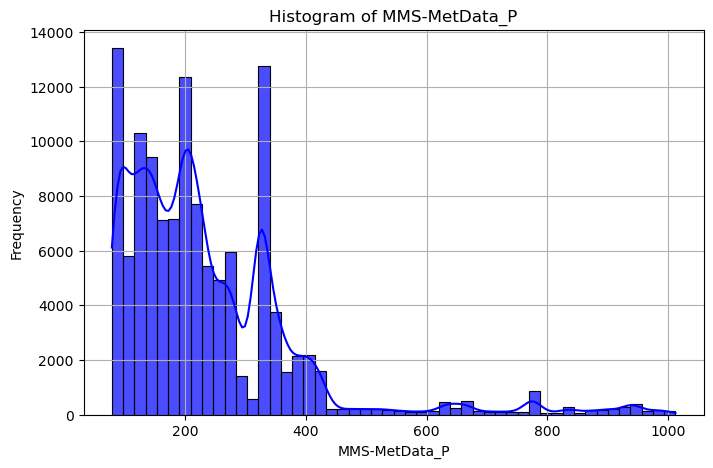

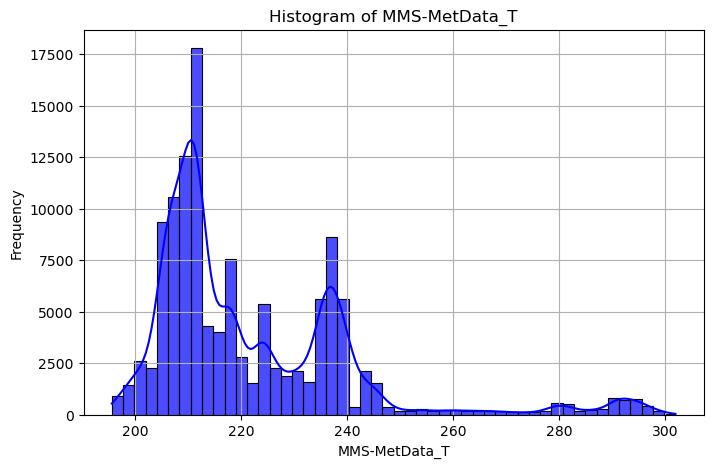

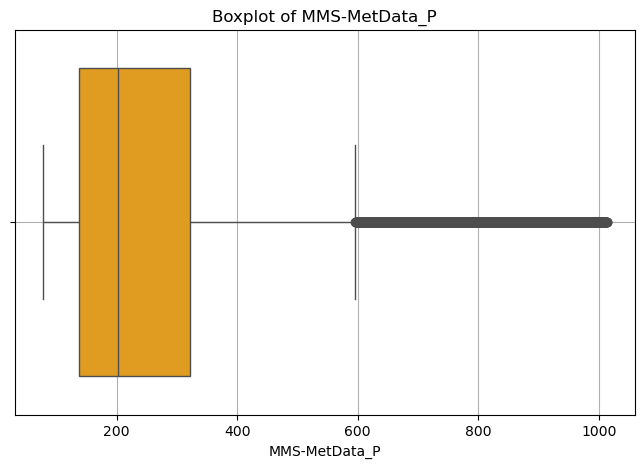

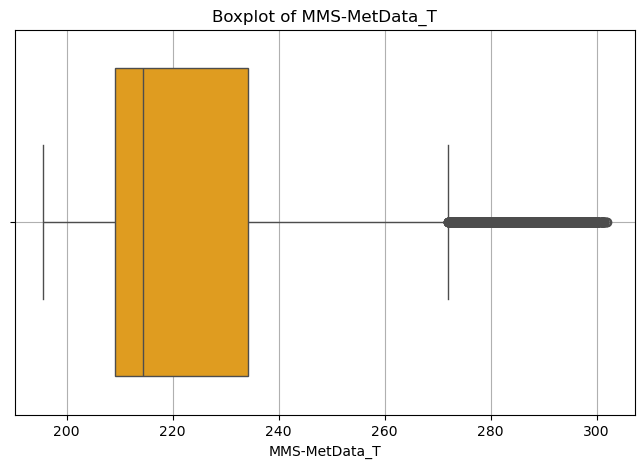

In [107]:
# Check distributions of temperature and pressure
# Check descriptive statistics for pressure and temperature
print("Descriptive Statistics for Pressure and Temperature:")
print(combined_df[['MMS-MetData_P', 'MMS-MetData_T']].describe())

# Plot histograms for pressure and temperature
def plot_histograms(df, columns, bins=50):
    for col in columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df[col].dropna(), kde=True, bins=bins, color='blue', alpha=0.7)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()

# Plot boxplots for pressure and temperature
def plot_boxplots(df, columns):
    for col in columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=df[col].dropna(), color='orange')
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)
        plt.grid(True)
        plt.show()

# Columns to analyze
columns = ['MMS-MetData_P', 'MMS-MetData_T']

# Plot histograms
plot_histograms(combined_df, columns)

# Plot boxplots
plot_boxplots(combined_df, columns)

In [108]:
# Calculate Si using different vapor measurements
def calculate_supersaturation(df, temp_col, pressure_col, vapor_col, output_col):
    """
    Calculate supersaturation with respect to ice (Si) and add as a new column.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame containing temperature, pressure, and vapor mixing ratio.
    temp_col : str
        Column name for temperature (in Celsius).
    pressure_col : str
        Column name for pressure (in hPa).
    vapor_col : str
        Column name for water vapor mixing ratio (in ppmv).
    output_col : str
        Name of the new column to store supersaturation with respect to ice.
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with the new column added.
    """
    T = df[temp_col] # temp in K
    
    # Calculate saturation vapor pressure over ice (e_s) in hPa
    e_s = 6.112 * np.exp((22.46 * (T - 273.15)) / (T - 0.55))
    
    # Convert vapor mixing ratio (ppmv) to actual vapor pressure (e) in hPa
    e = (df[vapor_col] / 1e6) * df[pressure_col]
    
    # Calculate supersaturation with respect to ice
    df[output_col] = (e / e_s) - 1
    
    return df

def calculate_all_supersaturations(df):
    """
    Calculate supersaturation with respect to ice for DLH-H2O, HWV, and JLH.
    """
    # Ensure required columns exist
    required_columns = [
        'MMS-MetData_T',  # Temperature in Celsius
        'MMS-MetData_P',  # Pressure in hPa
        'DLH-H2O_H2O_ppmv',  # Water vapor mixing ratio for DLH
        'HWV_H2O',  # Water vapor mixing ratio for HWV
        'JLH_H2O(v)_ppmv'  # Water vapor mixing ratio for JLH
    ]
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Required column '{col}' is missing from the DataFrame.")
    
    # Calculate supersaturation for each instrument
    df = calculate_supersaturation(df, 'MMS-MetData_T', 'MMS-MetData_P', 'DLH-H2O_H2O_ppmv', 'si_dlh')
    df = calculate_supersaturation(df, 'MMS-MetData_T', 'MMS-MetData_P', 'HWV_H2O', 'si_hwv')
    df = calculate_supersaturation(df, 'MMS-MetData_T', 'MMS-MetData_P', 'JLH_H2O(v)_ppmv', 'si_jlh')
    
    return df

# Example usage
# Assuming `combined_df` is the DataFrame with all the merged data
try:
    combined_df = calculate_all_supersaturations(combined_df)
    print("Supersaturation with respect to ice calculated and added as new columns.")
    print(combined_df[['datetime_utc', 'si_dlh', 'si_hwv', 'si_jlh']].head())
except ValueError as e:
    print(f"Error: {e}")

Supersaturation with respect to ice calculated and added as new columns.
         datetime_utc  si_dlh    si_hwv    si_jlh
0 2011-04-14 17:16:19     NaN -0.447797 -0.555534
1 2011-04-14 17:16:20     NaN       NaN -0.551646
2 2011-04-14 17:16:21     NaN       NaN       NaN
3 2011-04-14 17:16:22     NaN       NaN -0.538930
4 2011-04-14 17:16:23     NaN       NaN -0.523629


In [109]:
# List of Si columns
si_columns = ['si_dlh', 'si_hwv', 'si_jlh']

# Calculate percentage of valid (non-NaN) values for each column
valid_percentages = {}
for col in si_columns:
    valid_count = combined_df[col].notna().sum()
    total_count = len(combined_df)
    valid_percentages[col] = (valid_count / total_count) * 100

# Print the results
print("Percentage of valid values for each Si variable:")
for col, percentage in valid_percentages.items():
    print(f"{col}: {percentage:.2f}%")

Percentage of valid values for each Si variable:
si_dlh: 69.34%
si_hwv: 13.67%
si_jlh: 12.96%


In [110]:
# Define valid range for Si values
valid_range = (-1, 1)

# Create a new DataFrame to store the modified values
filtered_df = combined_df.copy()

# Replace values outside the valid range with NaN for each Si column
for col in ['si_dlh', 'si_hwv', 'si_jlh']:
    filtered_df[col] = combined_df[col].where(
        (combined_df[col] >= valid_range[0]) & (combined_df[col] <= valid_range[1])
    )

# Check the number of valid values after replacing out-of-range values with NaN
for col in ['si_dlh', 'si_hwv', 'si_jlh']:
    valid_count = filtered_df[col].notna().sum()
    total_count = len(filtered_df)
    print(f"{col}: {valid_count} valid values ({(valid_count / total_count) * 100:.2f}%)")

si_dlh: 84813 valid values (69.34%)
si_hwv: 16720 valid values (13.67%)
si_jlh: 15853 valid values (12.96%)


In [111]:
si_vars = ['si_dlh', 'si_hwv', 'si_jlh']
filtered_df[si_vars].describe()

,si_dlh,si_hwv,si_jlh
count,84813.000000,16720.000000,15853.000000
mean,-0.384519,-0.576556,-0.266176
std,0.407183,0.383708,0.224695
min,-0.982889,-0.981957,-0.973495
25%,-0.836421,-0.915092,-0.377502
50%,-0.319335,-0.762951,-0.271847
75%,-0.008463,-0.246383,-0.148747
max,0.641729,0.437183,0.736285


In [112]:
print(combined_df[['MMS-MetData_T', 'MMS-MetData_P', 'DLH-H2O_H2O_ppmv', 'HWV_H2O', 'JLH_H2O(v)_ppmv']].describe())
print(combined_df[['MMS-MetData_T', 'MMS-MetData_P', 'DLH-H2O_H2O_ppmv', 'HWV_H2O', 'JLH_H2O(v)_ppmv']].head(10))

       MMS-MetData_T  MMS-MetData_P  DLH-H2O_H2O_ppmv       HWV_H2O  \
count  122187.000000  122187.000000      84823.000000  16720.000000   
mean      221.800964     237.617663        396.608076    123.110920   
std        19.369373     151.344506       1913.997303    176.487034   
min       195.560000      78.200000         -2.320000      3.400000   
25%       209.150000     137.700000          6.160000      4.640000   
50%       214.370000     202.200000         46.630000     10.295000   
75%       234.290000     321.000000        429.170000    193.717500   
max       301.920000    1012.600000      25655.070000    599.680000   

       JLH_H2O(v)_ppmv  
count     15853.000000  
mean        208.483232  
std         143.653440  
min          10.010000  
25%          83.770000  
50%         144.930000  
75%         341.750000  
max         592.240000  
   MMS-MetData_T  MMS-MetData_P  DLH-H2O_H2O_ppmv  HWV_H2O  JLH_H2O(v)_ppmv
0         234.96          286.8               NaN   303.07 


Scatter Plots and Correlations:
Correlation between si_dlh and si_hwv: 0.997


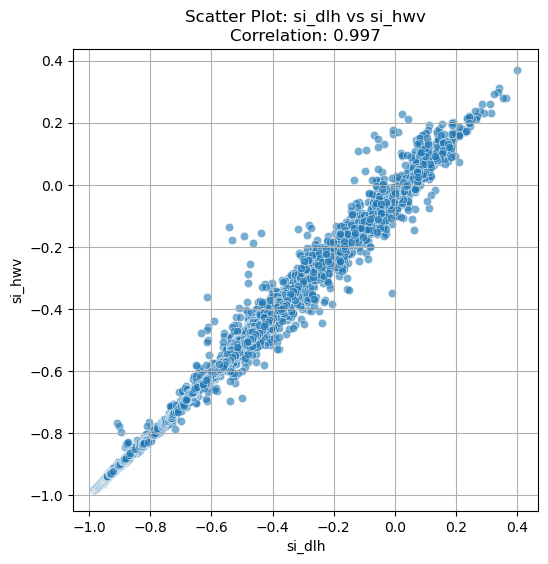

Correlation between si_dlh and si_jlh: 0.784


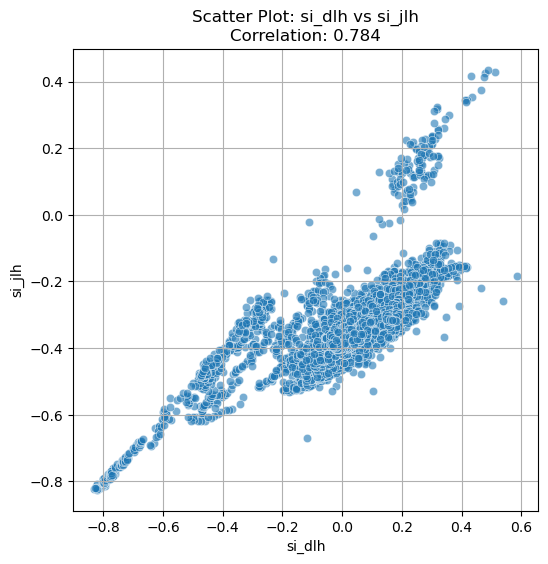

Correlation between si_hwv and si_jlh: 0.854


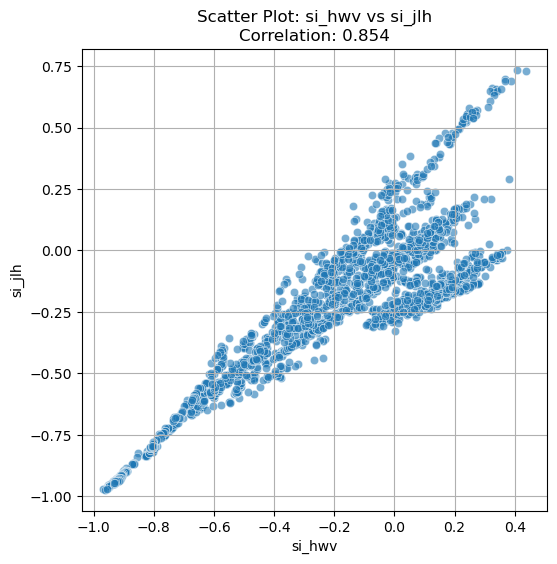

In [113]:
# Plot correlations between each combination of derived Si
def plot_scatter_and_correlation(df, si_columns):
    """
    Plot scatter plots and compute correlations for each combination of Si variables.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing Si variables.
    si_columns : list of str
        List of column names for Si variables.
    """
    print("\nScatter Plots and Correlations:")
    print("=" * 40)
    
    # Pairwise scatter plots and correlations
    for i, col1 in enumerate(si_columns):
        for col2 in si_columns[i+1:]:
            # Drop rows with NaN values for the two columns
            valid_data = df[[col1, col2]].dropna()
            
            # Compute correlation
            correlation = valid_data[col1].corr(valid_data[col2])
            print(f"Correlation between {col1} and {col2}: {correlation:.3f}")
            
            # Scatter plot
            plt.figure(figsize=(6, 6))
            sns.scatterplot(data=valid_data, x=col1, y=col2, alpha=0.6)
            plt.title(f"Scatter Plot: {col1} vs {col2}\nCorrelation: {correlation:.3f}")
            plt.xlabel(col1)
            plt.ylabel(col2)
            plt.grid(True)
            plt.show()


# Re-plot scatter plots and histograms after filtering
plot_scatter_and_correlation(filtered_df, ['si_dlh', 'si_hwv', 'si_jlh'])


Histogram Distributions:


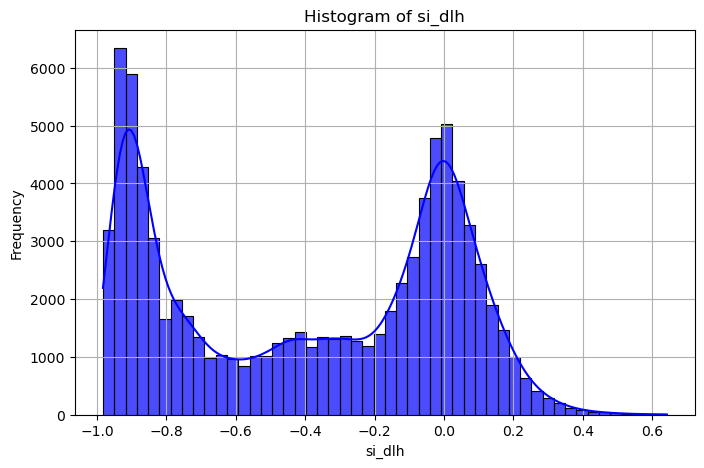

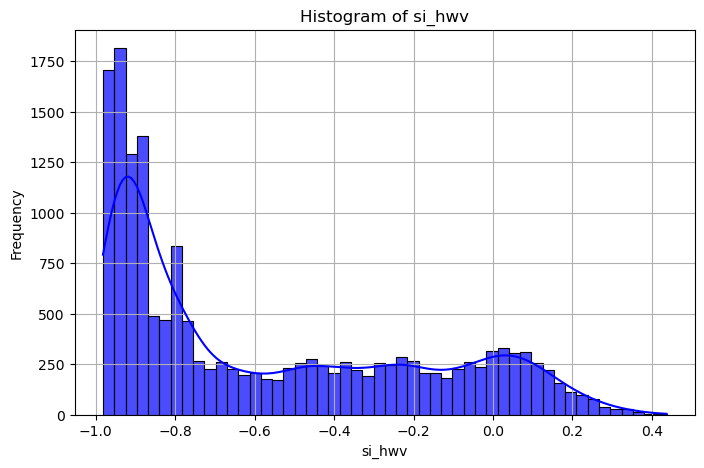

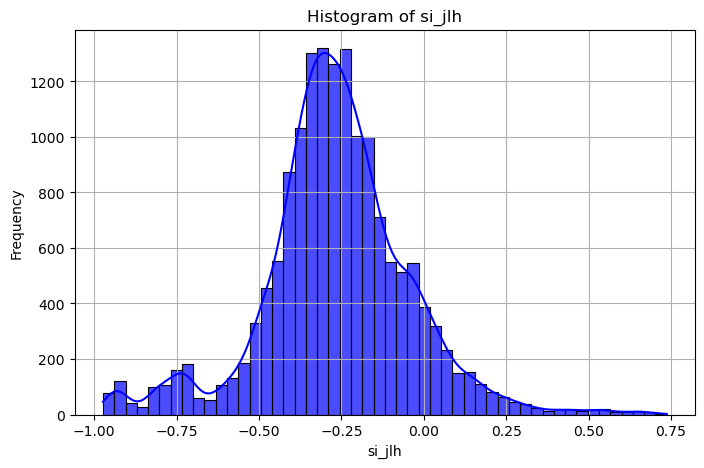

In [114]:
# Plot distributions of each derived Si variable

def plot_histograms(df, si_columns):
    """
    Plot histogram distributions for each Si variable.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing Si variables.
    si_columns : list of str
        List of column names for Si variables.
    """
    print("\nHistogram Distributions:")
    print("=" * 40)
    
    for col in si_columns:
        # Drop NaN values for the column
        valid_data = df[col].dropna()
        
        # Plot histogram
        plt.figure(figsize=(8, 5))
        sns.histplot(valid_data, kde=True, bins=50, color='blue', alpha=0.7)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()
        
# Plot histograms
plot_histograms(filtered_df, si_columns)

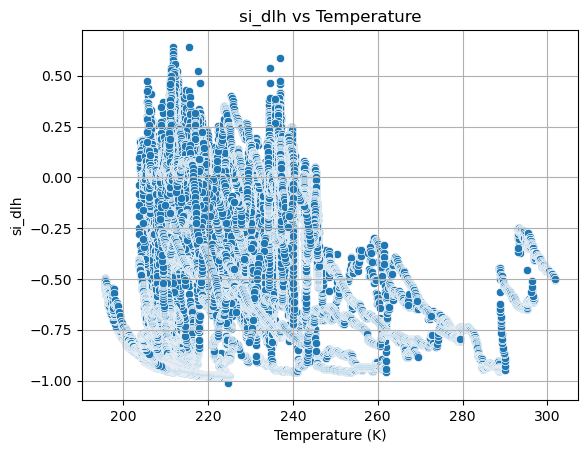

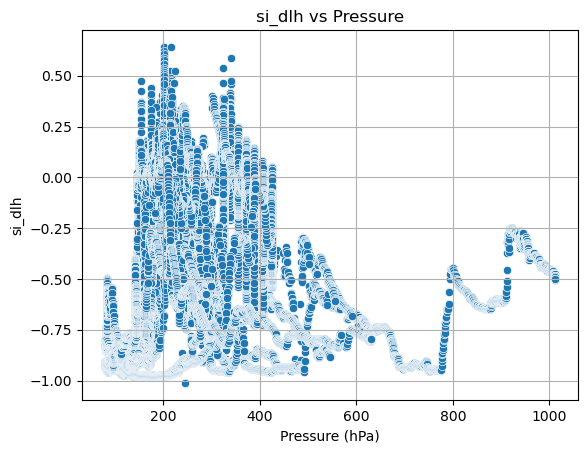

In [115]:
# Visualize Si vs. env variables
sns.scatterplot(x=combined_df['MMS-MetData_T'], y=combined_df['si_dlh'])
plt.xlabel('Temperature (K)')
plt.ylabel('si_dlh')
plt.title('si_dlh vs Temperature')
plt.grid(True)
plt.show()

sns.scatterplot(x=combined_df['MMS-MetData_P'], y=combined_df['si_dlh'])
plt.xlabel('Pressure (hPa)')
plt.ylabel('si_dlh')
plt.title('si_dlh vs Pressure')
plt.grid(True)
plt.show()

# POSIDON